# Identifying YS and Allantois trajectory in vivo

In [1]:
here::i_am("revisions/01_invivo_lineages/01_manual_trajectory.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [2]:
args = list()

# Metadata
args$metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz'

# RNA_sce
args$rna_sce = io$rna.atlas.sce

# outdir
args$outdir = file.path(io$basedir, 'results/revisions/01_invivo_lineages/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
meta = fread(args$metadata)

unique(meta$celltype)

[1] "Epiblast"                       "Primitive_Streak"              
 [3] "ExE_ectoderm"                   "Visceral_endoderm"             
 [5] "ExE_endoderm"                   "Nascent_mesoderm"              
 [7] "Rostral_neurectoderm"           "Blood_progenitors_2"           
 [9] "Mixed_mesoderm"                 "ExE_mesoderm"                  
[11] "Intermediate_mesoderm"          "Pharyngeal_mesoderm"           
[13] "Caudal_epiblast"                "PGC"                           
[15] "Mesenchyme"                     "Haematoendothelial_progenitors"
[17] "Blood_progenitors_1"            "Surface_ectoderm"              
[19] "Gut"                            "Paraxial_mesoderm"             
[21] "Caudal_neurectoderm"            "Notochord"                     
[23] "Somitic_mesoderm"               "Caudal_Mesoderm"               
[25] "Erythroid1"                     "Def._endoderm"                 
[27] "Parietal_endoderm"              "Allantois"                     
[29] "Anterior_Primitive_Streak"      "Endothelium"                   
[31] "Forebrain_Midbrain_Hindbrain"   "Spinal_cord"                   
[33] "Cardiomyocytes"                 "Erythroid2"                    
[35] "NMP"                            "Erythroid3"                    
[37] "Neural_crest"

In [4]:
rna.sce_full <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE)

In [5]:
# Only run this code if not ran at the beginning:

# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id %in% rownames(rna.sce_full)] %>%
  .[!duplicated(symbol)]

rna.sce_full = rna.sce_full[gene_metadata$ens_id,] # keep only genes with gene names

rownames(rna.sce_full) = gene_metadata[match(rownames(rna.sce_full), ens_id), symbol] # change rownames to gene names

In [6]:
# load meta
meta = fread(args$metadata)

celltypes = c(
              'Primitive_Streak',
              'Nascent_mesoderm',
              'Mixed_mesoderm',
              'Lateral_plate_mesoderm',
              'Allantois',
              'Haematoendothelial_progenitors', 
              'Blood_progenitors'
)

meta = meta[celltype_extended %in% celltypes]

In [7]:
# load sce
rna.sce <- rna.sce_full[,meta$cell]
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [8]:
source(here::here('rna/mapping/run/mnn/mapping_functions.R'))
library(batchelor)

# FastMNN batch correction

In [9]:
test = fastMNN(rna.sce, 
               batch = rna.sce$stage)

In [10]:
library(destiny)
DiffusionMap <- DiffusionMap(reducedDim(test,"corrected"))


Attaching package: ‘destiny’


The following object is masked from ‘package:SummarizedExperiment’:

    distance


The following object is masked from ‘package:GenomicRanges’:

    distance


The following object is masked from ‘package:IRanges’:

    distance


Warning message:
“as(<dsCMatrix>, "dsTMatrix") is deprecated since Matrix 1.5-0; do as(., "TsparseMatrix") instead”


In [11]:
test_bu = test

In [12]:
test <- runUMAP(test, dimred="corrected", n_neighbors = 35, min_dist = 0.15)

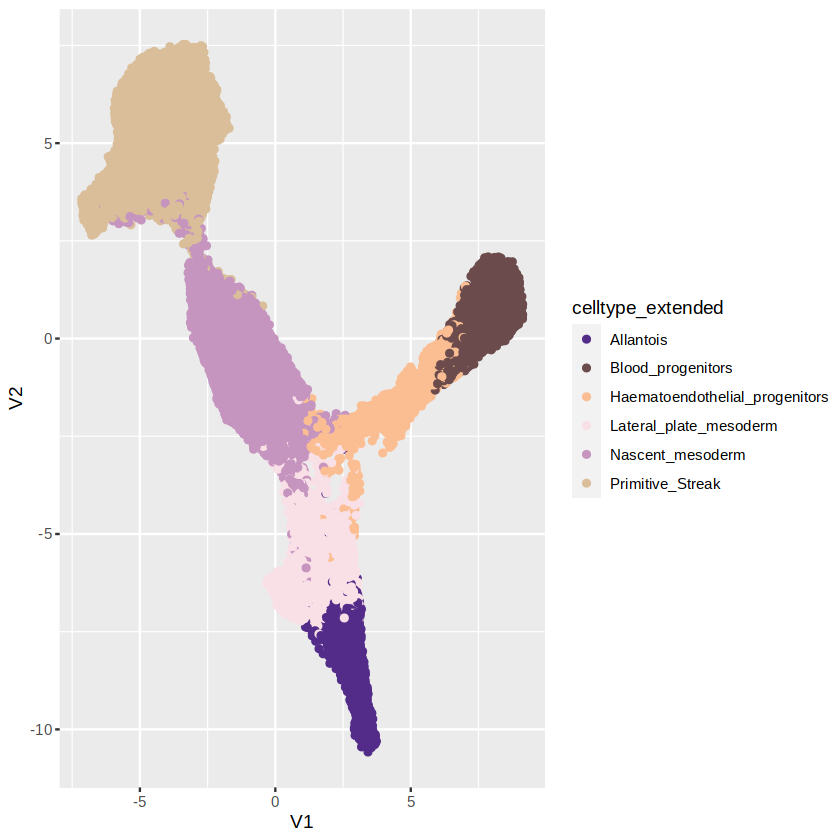

In [13]:
# Fetch UMAP coordinates
to.plot <- reducedDim(test,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(test)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(V1, V2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

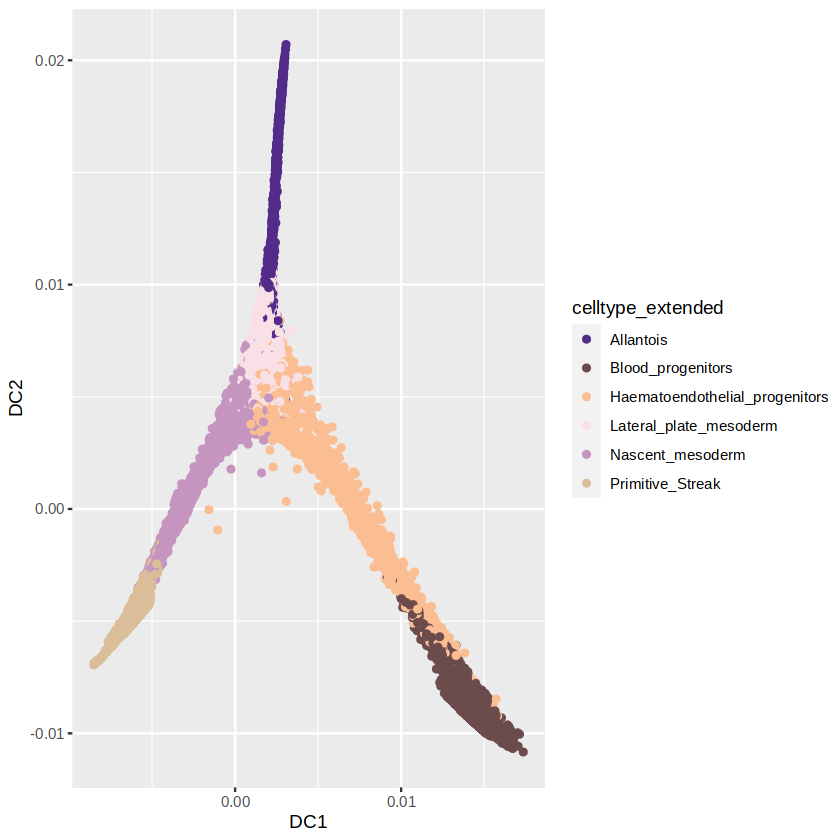

In [14]:
# Fetch UMAP coordinates
to.plot <- DiffusionMap@eigenvectors %>% as.data.table(., keep.rownames = T) %>% setnames('rn', 'cell') %>% 
    .[,cell:=colnames(test)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(DC1, DC2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

In [15]:
library(slingshot)

Loading required package: princurve

Loading required package: TrajectoryUtils


Attaching package: ‘TrajectoryUtils’


The following object is masked from ‘package:scran’:

    createClusterMST




In [16]:
test = test_bu
colData(test) = colData(rna.sce)

In [17]:
set.seed(42)
# Somehow it crashes if using all PCs.
reducedDim(test, "corrected2") <- reducedDim(test, "corrected")[,1:5] # 1:5 works fine?

test <- slingshot(test, 
                     clusterLabels = 'celltype_extended', 
                     start.clus = 'Primitive_Streak', 
                     omega = T, # play around until trajectories look good
                     shrink = T,
                     reducedDim='corrected2')

In [18]:
reducedDim(test, "diffusion") <- DiffusionMap@eigenvectors[,c(1:2)]

In [26]:
saveRDS(test, file.path(args$outdir, 'slingshot.rds'))

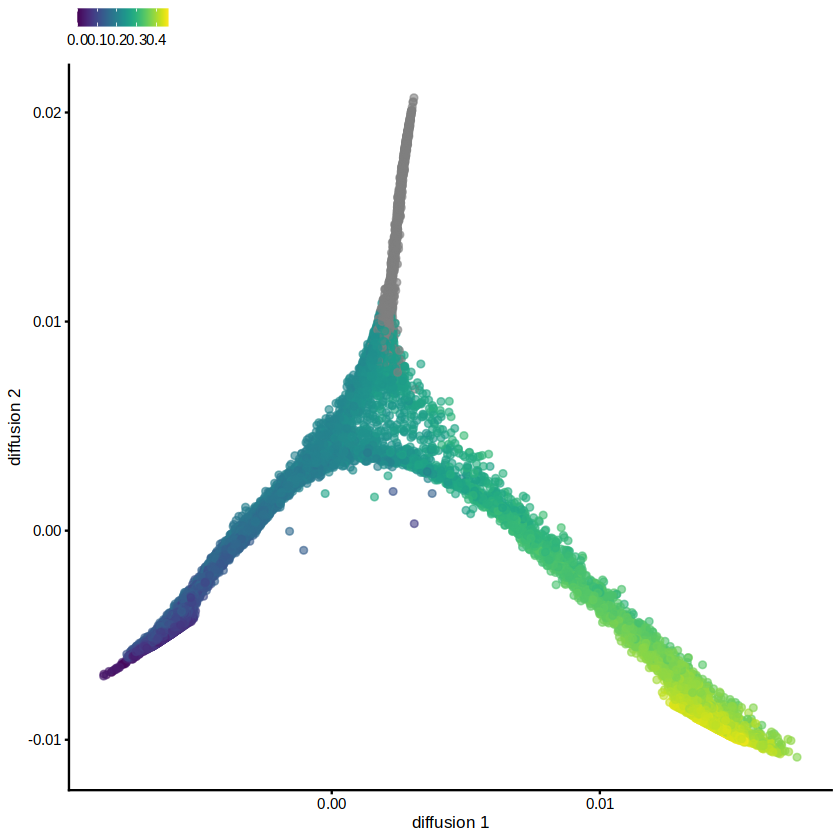

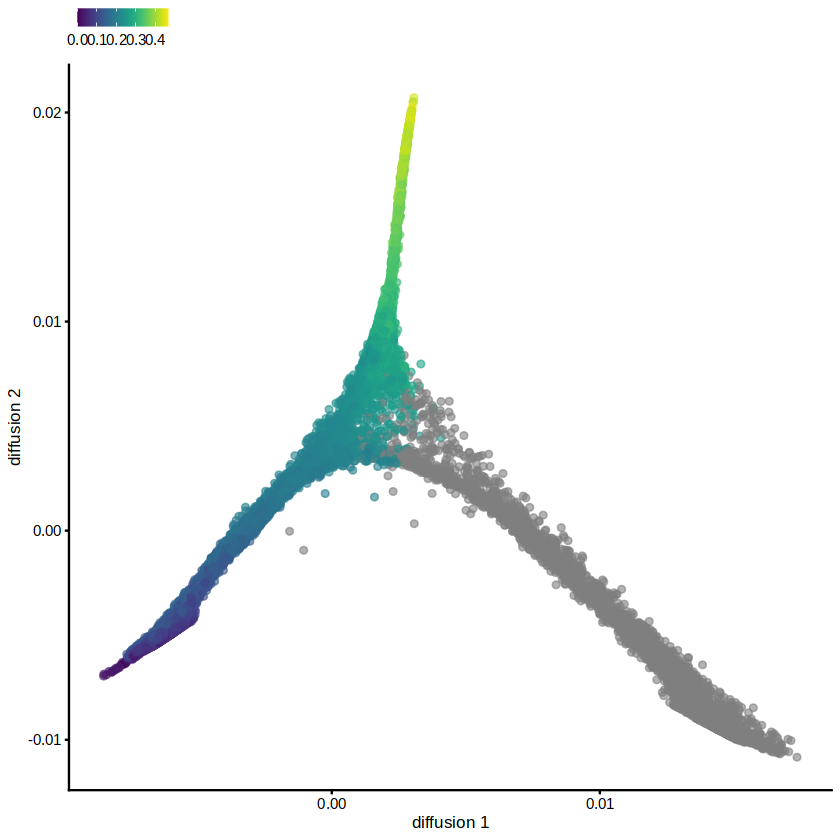

In [19]:
colData(test)$pseudotime = colData(test)$slingPseudotime_1 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame
plotReducedDim(test, dimred = "diffusion", colour_by="pseudotime", ncomponents = c(1,2)) +
    theme(legend.position="top", legend.title = element_blank())

colData(test)$pseudotime = colData(test)$slingPseudotime_2 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame
plotReducedDim(test, dimred = "diffusion", colour_by="pseudotime", ncomponents = c(1,2)) +
    theme(legend.position="top", legend.title = element_blank())

#### Don't use:

In [30]:
# Assign cells to lineages
set.seed(1234)
assign_lineages = tradeSeq:::.assignCells(assays(test$slingshot)$weights)
#colnames(assign_lineages) = c('Trajectory1', 'Trajectory2')
pseudotime = slingPseudotime(test$slingshot, na=T)

Traj_assignment = as.data.table(assign_lineages, keep.rownames=T) %>%
    setnames(c('cell', paste0('Trajectory', 1:(length(.)-1))))

In [31]:
meta2 = merge(meta, Traj_assignment)
meta2 = cbind(meta2, as.data.table(DiffusionMap@eigenvectors[meta2$cell,c(1:2)]))

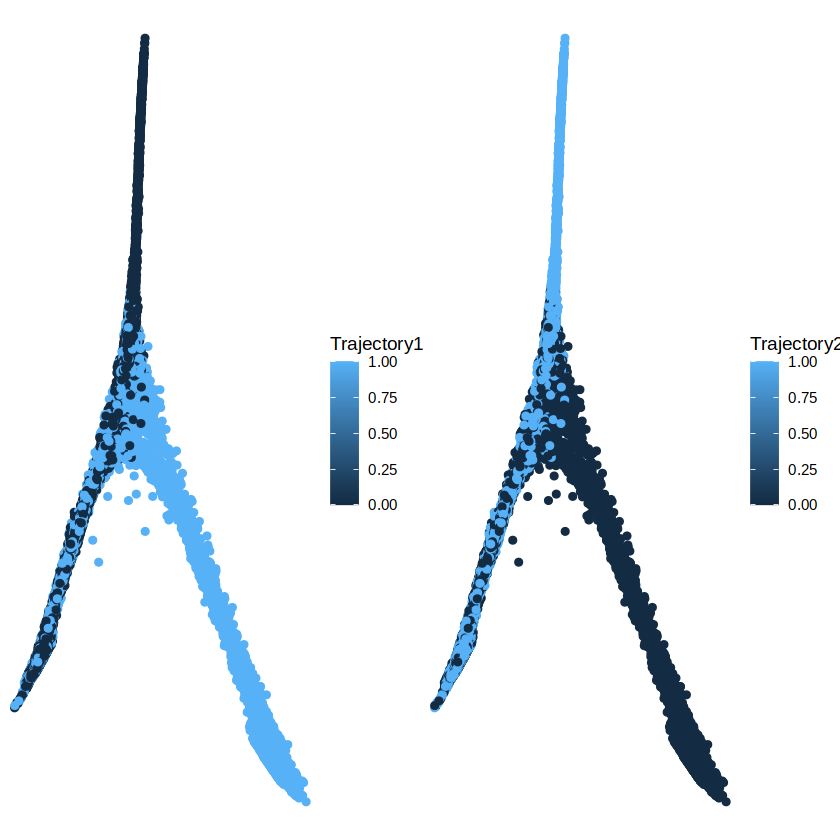

In [32]:
p1 = ggplot(meta2, aes(DC1, DC2, col = Trajectory1)) + 
    geom_point() + 
    theme_void()

p2 = ggplot(meta2, aes(DC1, DC2, col = Trajectory2)) + 
    geom_point() + 
    theme_void()

ggarrange(p1, p2)

In [33]:
# Keep only cells within pseudotime window for analysis
tmp = Traj_assignment
tmp2 = as.data.table(pseudotime, keep.rownames=T)
pseudo_min = 0
pseudo_max = 23

lineage1_keep = tmp2[rn %in% tmp[Trajectory1==1, cell]] %>% .[Lineage1 >= pseudo_min & Lineage1 <= pseudo_max] %>% .$rn
lineage2_keep = tmp2[rn %in% tmp[Trajectory2==1, cell]] %>% .[Lineage2 >= pseudo_min & Lineage2 <= pseudo_max] %>% .$rn

within_pseudotime_cells = c(lineage1_keep, lineage2_keep)

In [34]:
library(tradeSeq)

In [35]:
rna.sce <- rna.sce_full[,meta$cell]
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

decomp <- modelGeneVar(rna.sce[,within_pseudotime_cells])
decomp <- decomp[decomp$mean > 0.001, ]
decomp$FDR <- p.adjust(decomp$p.value, method = "fdr")
genes = as.data.table(decomp, keep.rownames = T) %>%
    .[order(FDR)] %>% head(10000) %>% .$rn

length(genes)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


[1] 10000

In [36]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 4

#U <- model.matrix(~as.factor(rna.sce$sample))
sceGAM <- fitGAM(counts = counts(rna.sce)[,within_pseudotime_cells], 
                 pseudotime = slingPseudotime(test$slingshot, na=F)[within_pseudotime_cells,],
                 cellWeights = assign_lineages[within_pseudotime_cells,],                 
                 #U = U, # Don't use replicates for test
                 nknots=8, 
                 genes = genes, # Only look at top 10k genes --> should probably reduce this further since it's already a ton, would improve FDR 
                 parallel = T,
                 BPPARAM=BPPARAM,
                 verbose=T)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 5.0 GiB”


  |======================================================================| 100%



In [37]:
saveRDS(sceGAM, file.path(args$outdir, 'sceGAM_v2.rds'))

In [3]:
sceGAM = readRDS(file.path(args$outdir, 'sceGAM_v2.rds'))

In [4]:
sceGAM

class: SingleCellExperiment 
dim: 10000 23754 
metadata(1): tradeSeq
assays(1): counts
rownames(10000): Phlda2 Tdgf1 ... Myo5c Gnb5
rowData names(1): tradeSeq
colnames(23754): cell_26 cell_33 ... cell_139256 cell_139316
colData names(2): crv tradeSeq
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [5]:
library(tradeSeq)

In [ ]:
patternRes <- patternTest(sceGAM, l2fc=1) # Perform pattern testing with set l2fc
patternGenes = patternRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>% # rename gene column
    .[waldStat != 0] %>% # Before multiple testing comparison, remove genes that do not qualify according to l2fc
    .[,padj:= p.adjust(pvalue, "fdr")] %>% # Multiple testing comparison
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] # Set significance
nrow(patternGenes[sig==TRUE])

In [ ]:
endRes <- diffEndTest(sceGAM, l2fc=1) # Perform pattern testing with set l2fc
endGenes = endRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>% # rename gene column
    .[waldStat != 0] %>% # Before multiple testing comparison, remove genes that do not qualify according to l2fc
    .[,padj:= p.adjust(pvalue, "fdr")] %>% # Multiple testing comparison
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] # Set significance
nrow(endGenes[sig==TRUE])

In [ ]:
fwrite(patternGenes, file.path(args$outdir, 'patternGenes_v2.txt.gz'))
fwrite(endGenes, file.path(args$outdir, 'endGenes_v2.txt.gz'))

In [6]:
patternGenes = fread(file.path(args$outdir, 'patternGenes_v2.txt.gz'))
endGenes = fread(file.path(args$outdir, 'endGenes_v2.txt.gz'))

In [7]:
genes_keep = unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene)

In [8]:
length(genes_keep)

[1] 2498

In [9]:
head(patternGenes[order(padj)])

gene,waldStat,df,pvalue,fcMedian,padj,sig
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<lgl>
Phlda2,8753.7047,8,0,0.32816514,0,TRUE
Mest,4503.9030,8,0,0.28033606,0,TRUE
Car2,3580.0248,7,0,0.42293891,0,TRUE
Cdkn1c,12447.9210,8,0,0.35418306,0,TRUE
Id3,1779.7676,8,0,0.04786798,0,TRUE
Cited4,735.0138,8,0,1.58778002,0,TRUE


In [10]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

# Get smoothed expession
yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

# Separate YS and Allantois trajectories
YS = yhatSmooth_minmax[, grepl('lineage1', colnames(yhatSmooth_minmax))] # again trajectory names are switched
Alnt = yhatSmooth_minmax[, grepl('lineage2', colnames(yhatSmooth_minmax))]

In [11]:
set.seed(42)
k = 10
group = kmeans(yhatSmooth_minmax, centers = k)$cluster

row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

In [12]:
# Specify which rows to annotate
rows_to_annotate <- c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10',  'Smad3','Sox6', 'Tbx4'
                     )
row_indices <- which(rownames(YS) %in% rows_to_annotate)
row_anno = rowAnnotation(link = anno_mark(at = row_indices, 
        labels = rownames(YS)[row_indices], 
        labels_gp = gpar(fontsize = 10), padding = unit(1, "mm")))

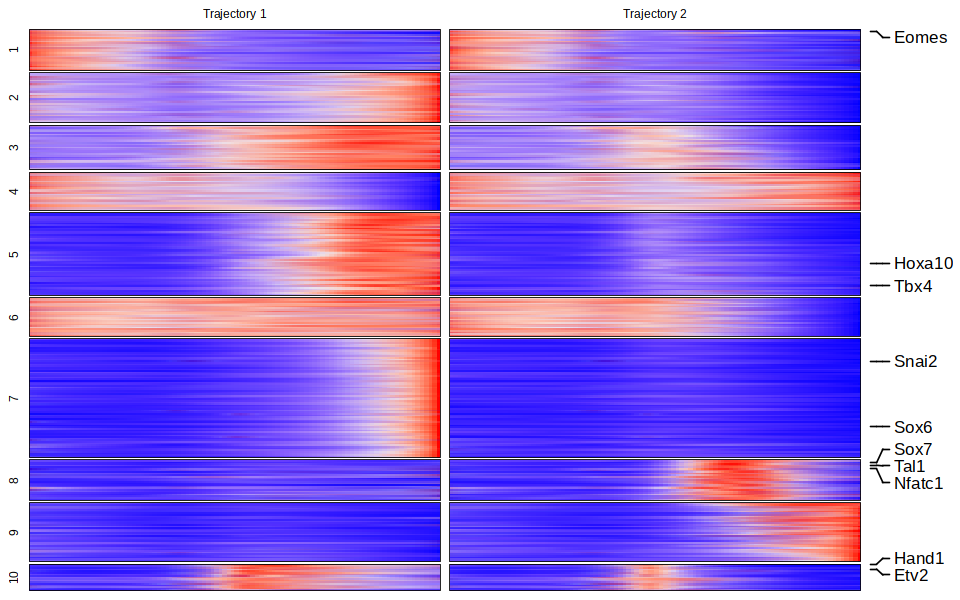

In [13]:
# Clustering
hm_list = Heatmap(Alnt, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 1',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          # col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
           # left_annotation = ha_row,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            # heatmap_legend_param = list(title = 'Expression'), 
            row_title_gp = gpar(fontsize = 7),
            column_title_gp = gpar(fontsize = 7),
           # top_annotation = ha_alnt,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1) + 
          Heatmap(YS, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 2',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          #  col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
            left_annotation = NULL,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            column_title_gp = gpar(fontsize = 7),
          #  top_annotation = ha_ys,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1
                 )

options(repr.plot.height=5, repr.plot.width=8)
plot = draw(hm_list + row_anno)

plot

In [14]:
genes = c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10', 'Sox6', 'Tbx4'
         )

genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('1'='chartreuse4', '2'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

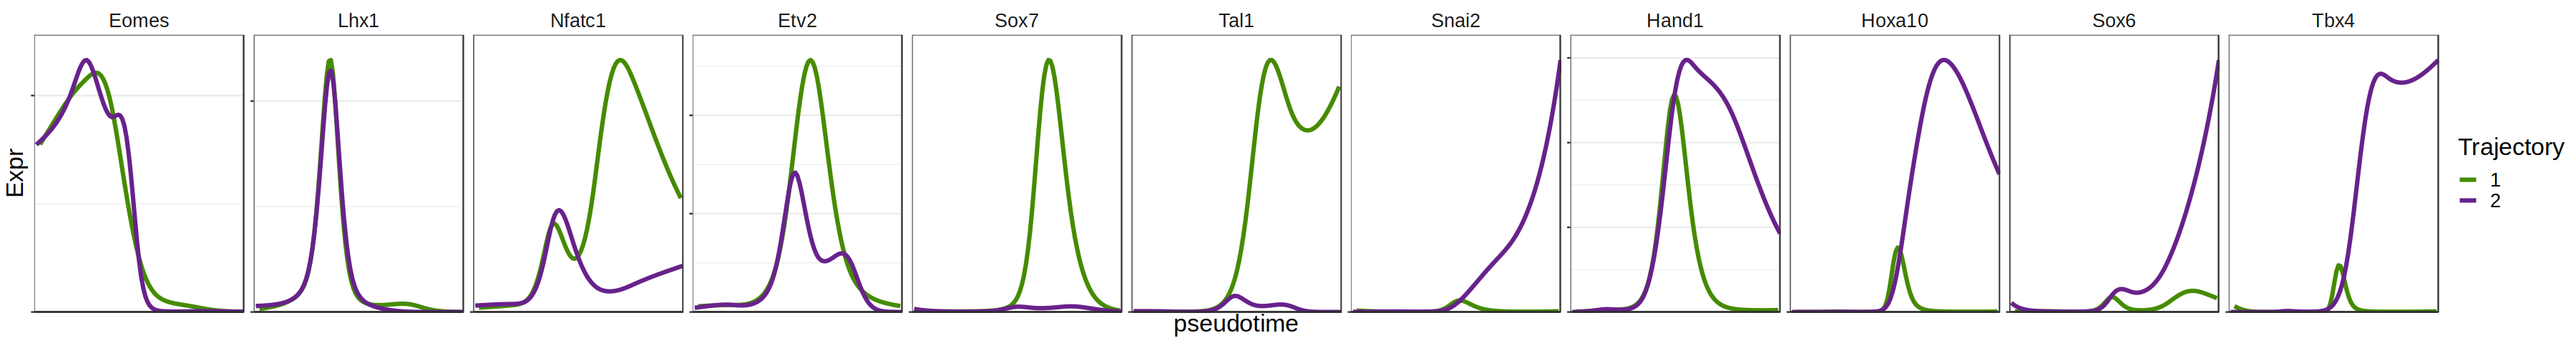

In [15]:
options(repr.plot.height=4, repr.plot.width=30)
p

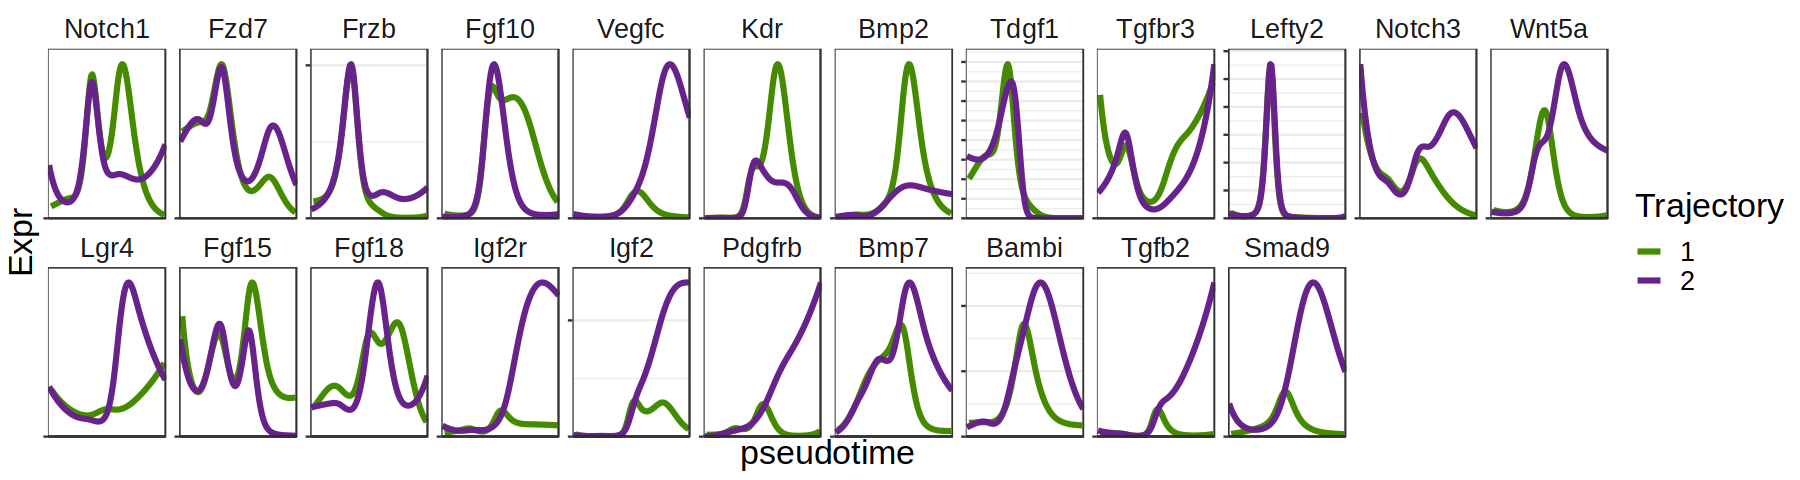

In [19]:
genes = c(
'Notch1','Fzd7',  'Frzb', 'Fgf10','Vegfc', 'Kdr','Bmp2','Tdgf1', 'Tgfbr3','Lefty2',
'Notch3', 'Wnt5a','Lgr4', 'Fgf15', 'Fgf18', 'Igf2r', 'Igf2', 'Pdgfrb', 'Bmp7', 'Bambi', 'Tgfb2', 'Smad9')
genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('1'='chartreuse4', '2'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

options(repr.plot.height=4, repr.plot.width=15)
p

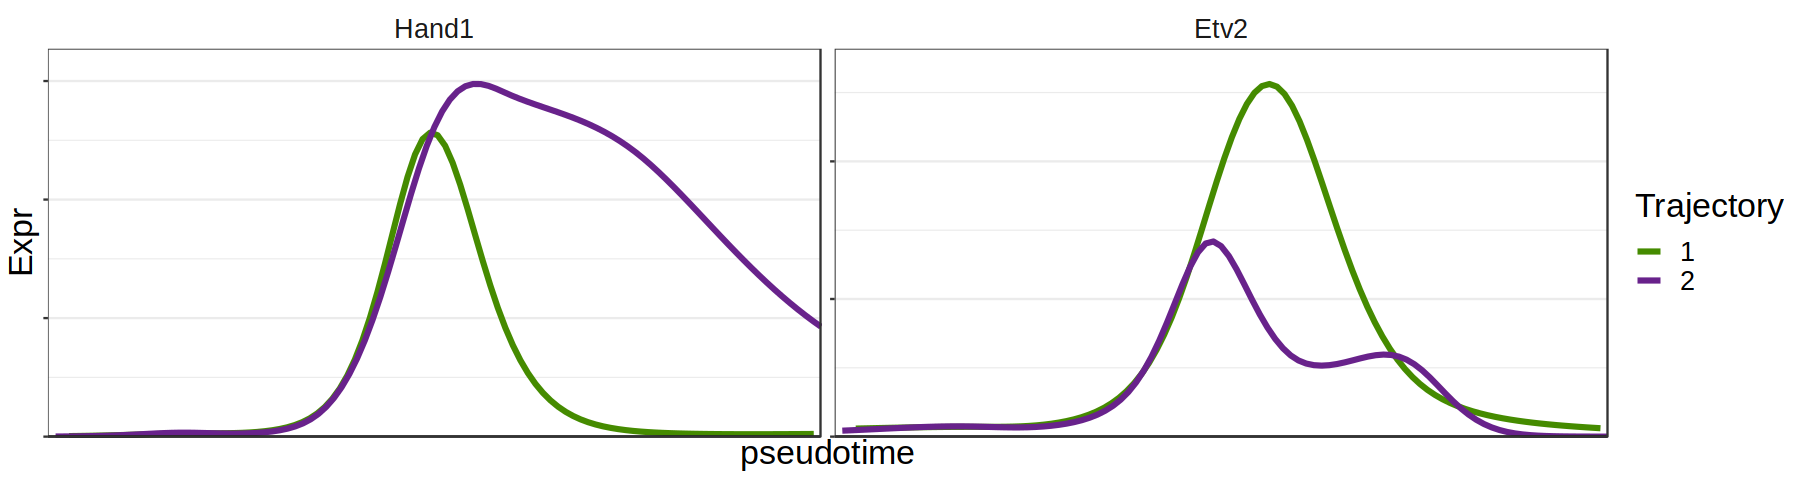

In [20]:
genes = c('Hand1', 'Etv2')
genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('1'='chartreuse4', '2'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

options(repr.plot.height=4, repr.plot.width=15)
p

## Limit pseudotime to better reflect in vitro data

In [9]:
test = readRDS(file.path(args$outdir, 'slingshot.rds'))

Loading required package: TrajectoryUtils


Attaching package: ‘TrajectoryUtils’


The following object is masked from ‘package:scran’:

    createClusterMST




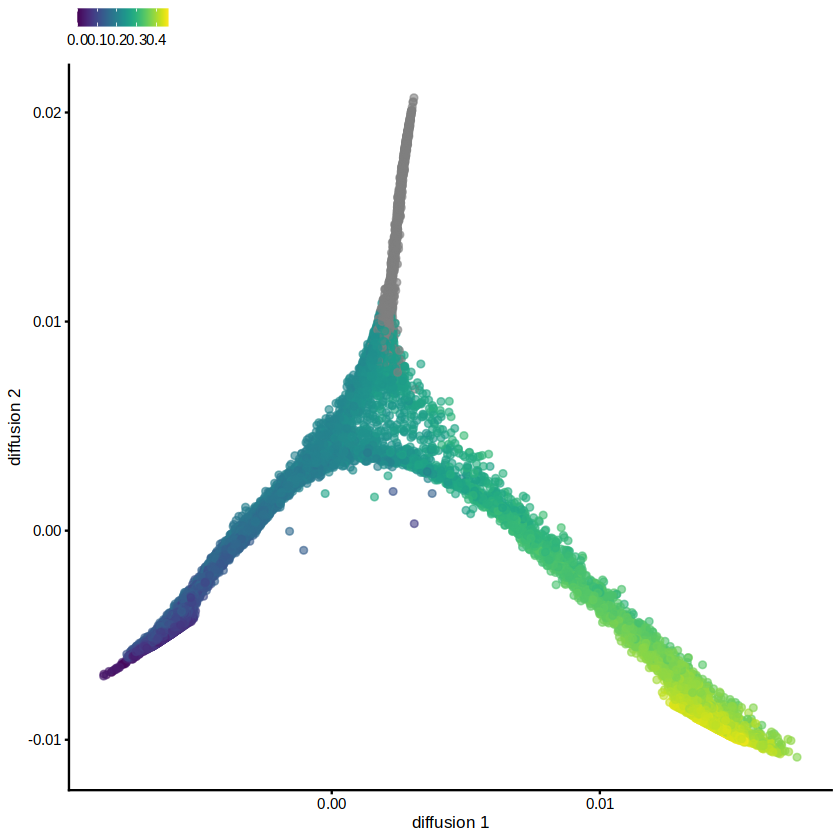

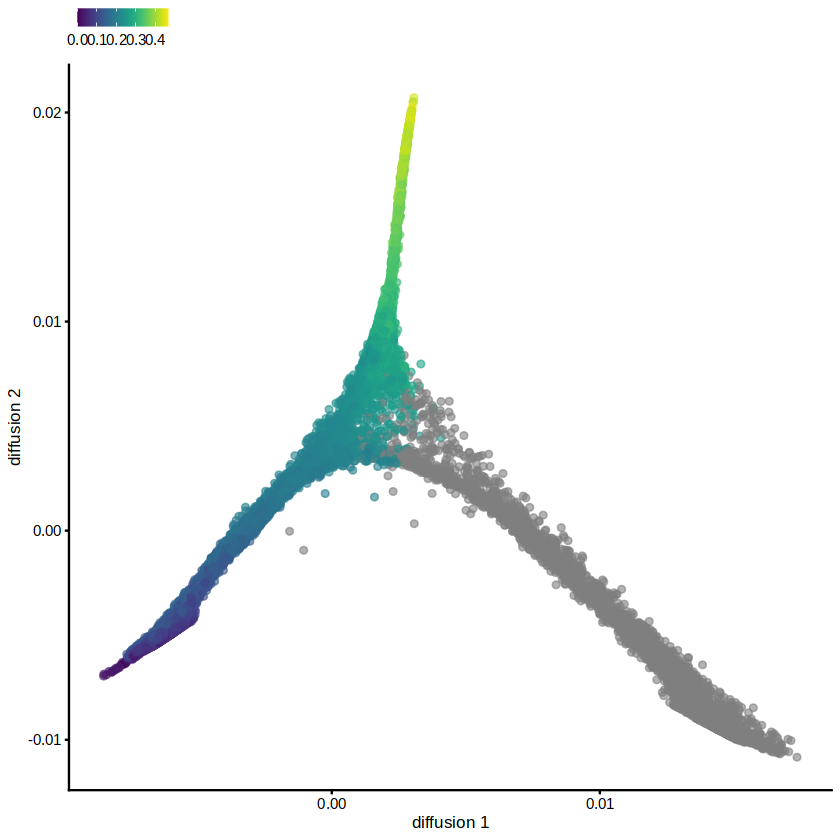

In [10]:
colData(test)$pseudotime = colData(test)$slingPseudotime_1 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame
plotReducedDim(test, dimred = "diffusion", colour_by="pseudotime", ncomponents = c(1,2)) +
    theme(legend.position="top", legend.title = element_blank())

colData(test)$pseudotime = colData(test)$slingPseudotime_2 # meta %>% tibble::column_to_rownames("cell") %>% DataFrame
plotReducedDim(test, dimred = "diffusion", colour_by="pseudotime", ncomponents = c(1,2)) +
    theme(legend.position="top", legend.title = element_blank())

In [11]:
library(slingshot)
library(destiny)

Loading required package: princurve


Attaching package: ‘destiny’


The following object is masked from ‘package:SummarizedExperiment’:

    distance


The following object is masked from ‘package:GenomicRanges’:

    distance


The following object is masked from ‘package:IRanges’:

    distance




In [12]:
# Assign cells to lineages
set.seed(1234)
assign_lineages = tradeSeq:::.assignCells(assays(test$slingshot)$weights)
#colnames(assign_lineages) = c('Trajectory1', 'Trajectory2')
pseudotime = slingPseudotime(test$slingshot, na=T)

Traj_assignment = as.data.table(assign_lineages, keep.rownames=T) %>%
    setnames(c('cell', paste0('Trajectory', 1:(length(.)-1))))

In [13]:
meta2 = merge(meta, Traj_assignment)
meta2 = cbind(meta2, as.data.table(reducedDims(test)$diffusion[meta2$cell,c(1:2)]))

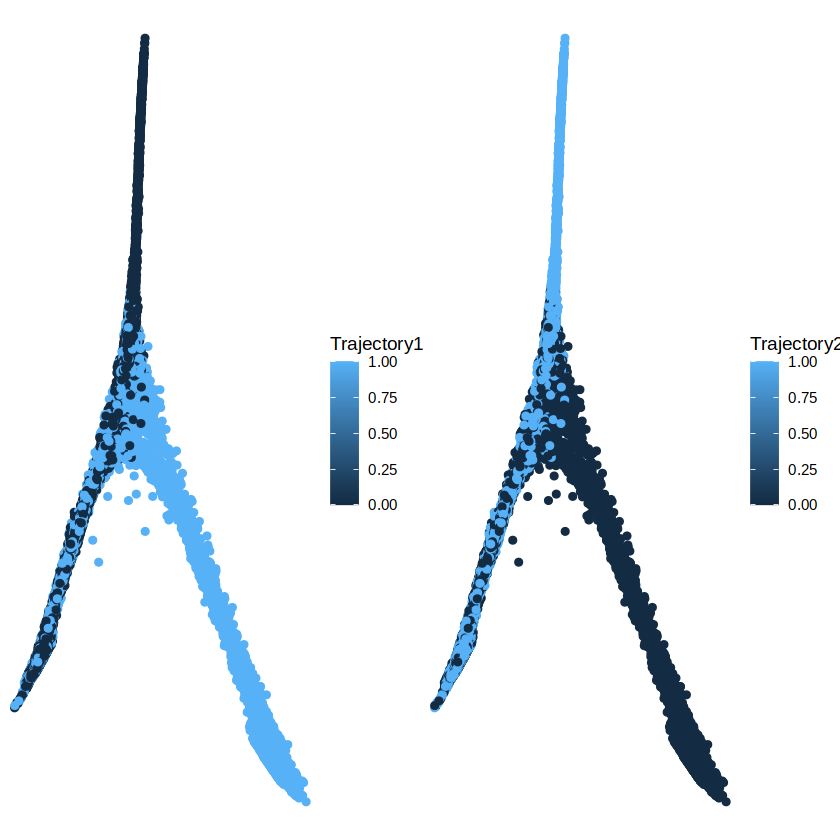

In [14]:
p1 = ggplot(meta2, aes(DC1, DC2, col = Trajectory1)) + 
    geom_point() + 
    theme_void()

p2 = ggplot(meta2, aes(DC1, DC2, col = Trajectory2)) + 
    geom_point() + 
    theme_void()

ggarrange(p1, p2)

In [15]:
# Keep only cells within pseudotime window for analysis
tmp = Traj_assignment
tmp2 = as.data.table(pseudotime, keep.rownames=T)
pseudo_min = 0
pseudo_max = 0.3

lineage1_keep = tmp2[rn %in% tmp[Trajectory1==1, cell]] %>% .[Lineage1 >= pseudo_min & Lineage1 <= pseudo_max] %>% .$rn
lineage2_keep = tmp2[rn %in% tmp[Trajectory2==1, cell]] %>% .[Lineage2 >= pseudo_min & Lineage2 <= pseudo_max] %>% .$rn

within_pseudotime_cells = c(lineage1_keep, lineage2_keep)

In [16]:
meta_plot = as.data.table(colData(test)[,-grep('slingshot', colnames(colData(test)))], keep.rownames = T) %>%
    setnames('rn', 'cell') %>%
    cbind(., tmp[match(.$cell, cell)][,-'cell']) %>%
    .[,pseudotime := ifelse(Trajectory1 == 1, slingPseudotime_1, 
                            ifelse(Trajectory2 == 1, slingPseudotime_2, NA))]

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [18]:
meta_atlas = fread(io$rna.atlas.metadata)

In [19]:
palette1 <- colorRampPalette(c("darkblue", "orange", "chartreuse", 'chartreuse4')) # YS trajectory palette
palette2 <- colorRampPalette(c("darkblue", "orange", "orchid1", 'darkorchid4'))  # Alnt trajectory palette

t1 = ggplot(meta_plot[Trajectory1 == 1], aes(umapX, umapY, color = pseudotime)) + 
    ggrastr::rasterise(geom_point(data = meta_atlas, 
               color='black', size = -0.05), dpi = 600) + 
    ggrastr::rasterise(geom_point(data = meta_atlas, 
               color='grey90', size = -0.15), dpi = 600) + 
    geom_point(size = 0.1) + 
    #viridis::scale_color_viridis() +
    scale_color_gradientn(colors = c("darkblue", "orange", "chartreuse", 'chartreuse4'),
                         guide = guide_colorbar(
                            barwidth = 3, barheight = 0.5,
                            frame.colour = "black",
                            ticks.colour = 'black')) + 
    coord_fixed(ratio = 0.75) + 
    theme_void() + 
    theme(legend.text = element_text(size = 6),
          legend.title = element_text(size = 7),
          legend.position = 'bottom')

t2 = ggplot(meta_plot[Trajectory2 == 1], aes(umapX, umapY, color = pseudotime)) + 
    ggrastr::rasterise(geom_point(data = meta_atlas, 
               color='black', size = -0.05), dpi = 600) + 
    ggrastr::rasterise(geom_point(data = meta_atlas, 
               color='grey90', size = -0.15), dpi = 600) +     
    geom_point(size = 0.1) + 
    #viridis::scale_color_viridis() +
    scale_color_gradientn(colors = c("darkblue", "orange", "orchid1", 'darkorchid4'),
                            guide = guide_colorbar(
                            barwidth = 3, barheight = 0.5,
                            frame.colour = "black",
                            ticks.colour = 'black')) +   
    coord_fixed(ratio = 0.75) + 
    theme_void() + 
    theme(legend.text = element_text(size = 6),
          legend.title = element_text(size = 7),
          legend.position = 'bottom')

options(repr.plot.width=10, repr.plot.height=5)
#ggarrange(t1, t2)

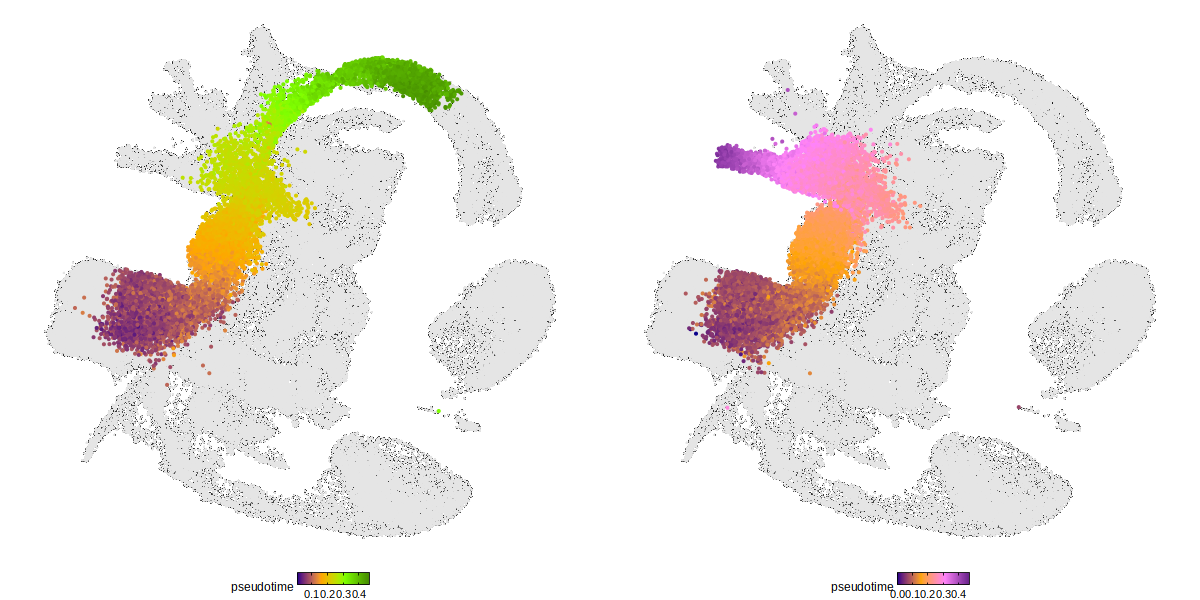

In [20]:
ggarrange(t1, t2)

In [21]:
ggsave(file.path(args$outdir, 'invivo_umap_pseudotime.pdf'), 
       plot = ggarrange(t1, t2), 
       width = 120, height = 60, units = "mm")

In [22]:
length(within_pseudotime_cells)

[1] 18536

In [23]:
library(tradeSeq)

In [24]:
rna.sce <- rna.sce_full[,meta$cell]
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

decomp <- modelGeneVar(rna.sce[,within_pseudotime_cells])
decomp <- decomp[decomp$mean > 0.001, ]
decomp$FDR <- p.adjust(decomp$p.value, method = "fdr")
genes = as.data.table(decomp, keep.rownames = T) %>%
    .[order(FDR)] %>% head(10000) %>% .$rn

length(genes)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


[1] 10000

In [ ]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 4

#U <- model.matrix(~as.factor(rna.sce$sample))
sceGAM <- fitGAM(counts = counts(rna.sce)[, within_pseudotime_cells], 
                 pseudotime = slingPseudotime(test$slingshot, na=F)[within_pseudotime_cells,],
                 cellWeights = assign_lineages[within_pseudotime_cells,],                 
                 #U = U, # Don't use replicates for test
                 nknots=8, 
                 genes = genes, # Only look at top 10k genes --> should probably reduce this further since it's already a ton, would improve FDR 
                 parallel = T,
                 BPPARAM=BPPARAM,
                 verbose=T)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.9 GiB”


  |==========                                                            |  15%

In [ ]:
genes = c('Eomes', 'Etv2')
genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('1'='chartreuse4', '2'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

options(repr.plot.height=3, repr.plot.width=5)
p

In [ ]:
saveRDS(sceGAM, file.path(args$outdir, 'sceGAM_v2.rds'))

In [ ]:
sceGAM = readRDS(file.path(args$outdir, 'sceGAM_v2.rds'))

In [ ]:
sceGAM

In [ ]:
patternRes <- patternTest(sceGAM, l2fc=1) # Perform pattern testing with set l2fc
patternGenes = patternRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>% # rename gene column
    .[waldStat != 0] %>% # Before multiple testing comparison, remove genes that do not qualify according to l2fc
    .[,padj:= p.adjust(pvalue, "fdr")] %>% # Multiple testing comparison
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] # Set significance
nrow(patternGenes[sig==TRUE])

In [ ]:
endRes <- diffEndTest(sceGAM, l2fc=1) # Perform pattern testing with set l2fc
endGenes = endRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>% # rename gene column
    .[waldStat != 0] %>% # Before multiple testing comparison, remove genes that do not qualify according to l2fc
    .[,padj:= p.adjust(pvalue, "fdr")] %>% # Multiple testing comparison
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] # Set significance
nrow(endGenes[sig==TRUE])

In [ ]:
fwrite(patternGenes, file.path(args$outdir, 'patternGenes_v2.txt.gz'))
fwrite(endGenes, file.path(args$outdir, 'endGenes_v2.txt.gz'))

In [ ]:
patternGenes = fread(file.path(args$outdir, 'patternGenes_v2.txt.gz'))
endGenes = fread(file.path(args$outdir, 'endGenes_v2.txt.gz'))

In [ ]:
genes_keep = unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene)

In [ ]:
length(genes_keep)

In [ ]:
head(patternGenes[order(padj)])

In [ ]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

# Get smoothed expession
yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

# Separate YS and Allantois trajectories
YS = yhatSmooth_minmax[, grepl('lineage1', colnames(yhatSmooth_minmax))] # again trajectory names are switched
Alnt = yhatSmooth_minmax[, grepl('lineage2', colnames(yhatSmooth_minmax))]

In [ ]:
set.seed(42)
k = 10
group = kmeans(yhatSmooth_minmax, centers = k)$cluster

row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

In [ ]:
# Specify which rows to annotate
rows_to_annotate <- c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10',  'Smad3','Sox6', 'Tbx4'
                     )
row_indices <- which(rownames(YS) %in% rows_to_annotate)
row_anno = rowAnnotation(link = anno_mark(at = row_indices, 
        labels = rownames(YS)[row_indices], 
        labels_gp = gpar(fontsize = 10), padding = unit(1, "mm")))

In [ ]:
# Clustering
hm_list = Heatmap(Alnt, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 1',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          # col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
           # left_annotation = ha_row,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            # heatmap_legend_param = list(title = 'Expression'), 
            row_title_gp = gpar(fontsize = 7),
            column_title_gp = gpar(fontsize = 7),
           # top_annotation = ha_alnt,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1) + 
          Heatmap(YS, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 2',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          #  col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
            left_annotation = NULL,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            column_title_gp = gpar(fontsize = 7),
          #  top_annotation = ha_ys,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1
                 )

options(repr.plot.height=5, repr.plot.width=8)
plot = draw(hm_list + row_anno)

plot

In [ ]:
genes = c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10', 'Sox6', 'Tbx4'
         )

genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('1'='chartreuse4', '2'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

In [ ]:
options(repr.plot.height=4, repr.plot.width=30)
p

In [ ]:
genes = c(
'Notch1','Fzd7',  'Frzb', 'Fgf10','Vegfc', 'Kdr','Bmp2','Tdgf1', 'Tgfbr3','Lefty2',
'Notch3', 'Wnt5a','Lgr4', 'Fgf15', 'Fgf18', 'Igf2r', 'Igf2', 'Pdgfrb', 'Bmp7', 'Bambi', 'Tgfb2', 'Smad9')
genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('1'='chartreuse4', '2'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(1, 25, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                #  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

options(repr.plot.height=4, repr.plot.width=15)
p

In [ ]:
genes = c(
'Cxcr4')
genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)]

    p = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
        #    geom_point(size=0.2, alpha=0.2) +
            geom_line(linewidth = 1.3) + 
            scale_color_manual(values=c('1'='chartreuse4', '2'='darkorchid4'), name='Trajectory') + 
            scale_x_continuous(expand=c(0.01,0, 0, 0), breaks=c(seq(1, 25, 3))) + 
            scale_y_continuous(expand=c(0,0, 0.1, 0), breaks=seq(0, 1e3, 3)) + 
        #    geom_smooth(se = F) +
            geom_hline(yintercept=0) +
            facet_wrap(~gene, ncol=12, scales='free_y') + 
            theme_bw() + 
            theme(strip.background = element_blank(),
                  text = element_text(size=20),
                  axis.text = element_text(color='black'),
                #  axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
                  axis.text.y = element_blank())

options(repr.plot.height=4, repr.plot.width=4)
p

#### Plot in vitro multiome expression for those genes

In [ ]:
sceGAM_vitro = readRDS(file.path(io$basedir, 'results/rna_atac/trajectory/v3', 'sceGAM.rds'))

In [ ]:
genes_keep_vitro = genes_keep[genes_keep %in% rownames(sceGAM_vitro)]

In [ ]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

# Get smoothed expession
yhatSmooth <- predictSmooth(sceGAM_vitro, gene = genes_keep_vitro, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

# Separate YS and Allantois trajectories
YS = yhatSmooth_minmax[, grepl('lineage1', colnames(yhatSmooth_minmax))] # again trajectory names are switched
Alnt = yhatSmooth_minmax[, grepl('lineage2', colnames(yhatSmooth_minmax))]

In [ ]:
set.seed(42)
group_vitro = group[names(group) %in% rownames(sceGAM_vitro)]

row_clust = cluster_within_group(t(yhatSmooth_minmax), group_vitro)

In [ ]:
# Specify which rows to annotate
rows_to_annotate <- c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10',  'Smad3','Sox6', 'Tbx4'
                     )
row_indices <- which(rownames(YS) %in% rows_to_annotate)
row_anno = rowAnnotation(link = anno_mark(at = row_indices, 
        labels = rownames(YS)[row_indices], 
        labels_gp = gpar(fontsize = 10), padding = unit(1, "mm")))

In [ ]:
# Clustering
hm_list = Heatmap(Alnt, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 1',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          # col = cols,
            show_heatmap_legend = FALSE,
            row_split = group_vitro, 
           # left_annotation = ha_row,
            show_row_dend = FALSE,
            row_order = order(group_vitro, decreasing = TRUE),
            # heatmap_legend_param = list(title = 'Expression'), 
            row_title_gp = gpar(fontsize = 7),
            column_title_gp = gpar(fontsize = 7),
           # top_annotation = ha_alnt,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1) + 
          Heatmap(YS, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 2',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          #  col = cols,
            show_heatmap_legend = FALSE,
            row_split = group_vitro, 
            left_annotation = NULL,
            show_row_dend = FALSE,
            row_order = order(group_vitro, decreasing = TRUE),
            column_title_gp = gpar(fontsize = 7),
          #  top_annotation = ha_ys,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1
                 )

options(repr.plot.height=5, repr.plot.width=8)
plot = draw(hm_list + row_anno)

plot

In [ ]:
set.seed(42)
k = 10
group = kmeans(yhatSmooth_minmax, centers = k)$cluster

row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

In [ ]:
# Specify which rows to annotate
rows_to_annotate <- c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10',  'Smad3','Sox6', 'Tbx4'
                     )
row_indices <- which(rownames(YS) %in% rows_to_annotate)
row_anno = rowAnnotation(link = anno_mark(at = row_indices, 
        labels = rownames(YS)[row_indices], 
        labels_gp = gpar(fontsize = 10), padding = unit(1, "mm")))

In [ ]:
# Clustering
hm_list = Heatmap(Alnt, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 1',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          # col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
           # left_annotation = ha_row,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            # heatmap_legend_param = list(title = 'Expression'), 
            row_title_gp = gpar(fontsize = 7),
            column_title_gp = gpar(fontsize = 7),
           # top_annotation = ha_alnt,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1) + 
          Heatmap(YS, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 2',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          #  col = cols,
            show_heatmap_legend = FALSE,
            row_split = group, 
            left_annotation = NULL,
            show_row_dend = FALSE,
            row_order = order(group, decreasing = TRUE),
            column_title_gp = gpar(fontsize = 7),
          #  top_annotation = ha_ys,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1
                 )

options(repr.plot.height=5, repr.plot.width=8)
plot = draw(hm_list + row_anno)

plot

#### In vivo expression for in vitro genes

In [ ]:
sceGAM = readRDS(file.path(args$outdir, 'sceGAM_v2.rds'))

In [ ]:
library(tradeSeq)

In [ ]:
patternGenes = fread(file.path(io$basedir, 'results/rna_atac/trajectory/v3', 'patternGenes.txt.gz'))
endGenes = fread(file.path(io$basedir, 'results/rna_atac/trajectory/v3', 'endGenes.txt.gz'))

In [ ]:
genes_keep = unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene)

In [ ]:
sceGAM_vitro = readRDS(file.path(io$basedir, 'results/rna_atac/trajectory/v3', 'sceGAM.rds'))

In [ ]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

# Get smoothed expession
yhatSmooth <- predictSmooth(sceGAM_vitro, gene = genes_keep, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

# Separate YS and Allantois trajectories
YS = yhatSmooth_minmax[, grepl('lineage1', colnames(yhatSmooth_minmax))] # again trajectory names are switched
Alnt = yhatSmooth_minmax[, grepl('lineage2', colnames(yhatSmooth_minmax))]

In [ ]:
# Clustering of genes & re-annotating in order of expression
set.seed(42)
k = 10
group = kmeans(yhatSmooth_minmax, centers = k)$cluster

group_rename = c(
    '3' = '1',
    '7' = '2', 
    '9' = '3', 
    '10' = '4',                
    '2' = '5',
    '6' = '6', 
    '4' = '7',
    '8' = '8', 
    '1' = '9', 
    '5' = '10'
)

tmp = group
group = as.integer(group_rename[match(group, names(group_rename))])
names(group) = names(tmp)
row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

In [ ]:
genes_keep = genes_keep[genes_keep %in% rownames(sceGAM)]
group_keep = group[names(group) %in% rownames(sceGAM)]

In [ ]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

# Get smoothed expession
yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

# Separate YS and Allantois trajectories
YS = yhatSmooth_minmax[, grepl('lineage1', colnames(yhatSmooth_minmax))] # again trajectory names are switched
Alnt = yhatSmooth_minmax[, grepl('lineage2', colnames(yhatSmooth_minmax))]

In [ ]:
set.seed(42)
group_vitro = group_keep #[names(group) %in% rownames(sceGAM_vitro)]

row_clust = cluster_within_group(t(yhatSmooth_minmax), group_vitro)

In [ ]:
# Specify which rows to annotate
rows_to_annotate <- c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10',  'Smad3','Sox6', 'Tbx4'
                     )
row_indices <- which(rownames(YS) %in% rows_to_annotate)
row_anno = rowAnnotation(link = anno_mark(at = row_indices, 
        labels = rownames(YS)[row_indices], 
        labels_gp = gpar(fontsize = 10), padding = unit(1, "mm")))

In [ ]:
# Clustering
hm_list = Heatmap(Alnt, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 1',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          # col = cols,
            show_heatmap_legend = FALSE,
            row_split = group_keep, 
           # left_annotation = ha_row,
            show_row_dend = FALSE,
            row_order = order(group_keep, decreasing = TRUE),
            # heatmap_legend_param = list(title = 'Expression'), 
            row_title_gp = gpar(fontsize = 7),
            column_title_gp = gpar(fontsize = 7),
           # top_annotation = ha_alnt,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1) + 
          Heatmap(YS, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 2',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
          #  col = cols,
            show_heatmap_legend = FALSE,
            row_split = group_keep, 
            left_annotation = NULL,
            show_row_dend = FALSE,
            row_order = order(group_keep, decreasing = TRUE),
            column_title_gp = gpar(fontsize = 7),
          #  top_annotation = ha_ys,
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1
                 )

options(repr.plot.height=5, repr.plot.width=8)
plot = draw(hm_list + row_anno)

plot

In [ ]:
pdf(file = file.path(args$outdir, 'invivo_expression_vitro_genes.pdf'), 
   height = 3, 
   width = 2)
    draw(hm_list)
dev.off()

In [ ]:
# Specify which rows to annotate
rows_to_annotate <- c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10',  'Smad3','Sox6', 'Tbx4'
                     )
row_indices <- which(rownames(YS) %in% rows_to_annotate)
row_anno = rowAnnotation(link = anno_mark(at = row_indices, 
        labels = rownames(YS)[row_indices], 
        labels_gp = gpar(fontsize = 10), padding = unit(1, "mm")))

In [ ]:
# Clustering
## Values color palette
trans <- div_gradient_pal(low='#5a77ff', mid='lightyellow', high='#d66468')
cols <- trans(seq(0,1, length.out=20))

hm_list = Heatmap(Alnt, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 1',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
            show_heatmap_legend = FALSE,
            row_split = group_keep, 
              col = cols,
           # left_annotation = ha_row,
            show_row_dend = FALSE,
            row_order = order(group_keep, decreasing = TRUE),
            # heatmap_legend_param = list(title = 'Expression'), 
            row_title_gp = gpar(fontsize = 7),
            column_title_gp = gpar(fontsize = 7),
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1) + 
          Heatmap(YS, 
           row_gap = unit(0.5, "mm"),
            cluster_columns = FALSE,
            column_title = 'Trajectory 2',
            show_column_names  = FALSE,
            show_row_names  = FALSE,
              col = cols,
            show_heatmap_legend = FALSE,
            row_split = group_keep, 
            left_annotation = NULL,
            show_row_dend = FALSE,
            row_order = order(group_keep, decreasing = TRUE),
            column_title_gp = gpar(fontsize = 7),
            border = TRUE,
            border_gp = gpar(col = "black", lwd = 0.5),
            use_raster = TRUE,
            raster_device = "png",
            raster_quality = 1
                 )

options(repr.plot.height=5, repr.plot.width=8)
plot = draw(hm_list)

In [ ]:
pdf(file = file.path(args$outdir, 'invivo_expression_vitro_genes.pdf'), 
   width = 1.85, 
   height = 2.5)
    draw(hm_list)
dev.off()

In [ ]:
genes = c('Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10', 'Sox6', 'Tbx4'
         )

genes = genes[genes %in% rownames(sceGAM)]
yhatSmooth <- predictSmooth(sceGAM, gene = genes, nPoints = 100, tidy=TRUE)

    RNA_filt.dt = as.data.table(yhatSmooth[yhatSmooth$gene %in% genes,]) %>% 
            setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
            .[,gene:=factor(gene, levels = genes)] %>%
            .[,Traj:=as.character(Traj)] %>%
            .[,Expr_minmax := minmax.normalisation(Expr), by = 'gene']

    p_TF = ggplot(RNA_filt.dt, aes(pseudotime, Expr_minmax, color=Traj)) + 
        geom_line() + 
        scale_color_manual(values=c('1'='chartreuse4', '2'='darkorchid4'), name='Trajectory') + 
        scale_x_continuous(expand=c(0.01, 0)) + 
        scale_y_continuous(expand=c(0,0, 0.05, 0), breaks = c(0,1), labels = c('Min', 'Max')) + 
        guides(color = guide_legend(nrow=2,byrow=TRUE),
               linetype = guide_legend(nrow = 2)) +
        geom_hline(yintercept=0, linewidth = 0) +
        facet_wrap(~gene, nrow=2, scales='fixed') + 
        ylab('Expr / Motif Acc') + xlab('Pseudotime') + 
        theme_bw() + 
        theme(strip.background = element_blank(),
                strip.text = element_text(size = 8, vjust = -0.5),
                text = element_text(size=6),
                axis.text = element_text(color='black', size = 6),
                axis.text.x = element_text(angle=0, hjust=0.5, vjust=1, size = 6),
                axis.title = element_text(size = 7),
                legend.text = element_text(size = 6),
                legend.title = element_text(size = 7),
                legend.position = 'right',
                legend.box = "horizontal",
                legend.key.size = unit(2, "mm"),
                panel.border = element_rect(color='black', linewidth=0.15, fill=NA),
                panel.background = element_blank(),
                axis.line = element_blank(),
                axis.line.x = element_blank(),
                axis.ticks = element_line(linewidth=0.1),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.spacing = unit(0.4, 'mm'),
                panel.spacing.y=unit(0, "lines"),
                plot.margin = margin(t = 0, r = 1, b = 0, l = 1)
)

In [ ]:
options(repr.plot.height=4, repr.plot.width=30)
p_TF

In [ ]:
ggsave(file.path(args$outdir, 'invivo_expression_vitro_genes_TFs.pdf'), 
       plot = p_TF + theme(legend.position = 'none'),
       width = 80, 
       height = 50, 
       units = "mm")

# subcluster nascent mesoderm

In [54]:
# load meta
meta = fread(args$metadata)

celltypes = c(
              'Nascent_mesoderm', 'Mixed_mesoderm'
)

meta = meta[celltype %in% celltypes]

In [55]:
# load sce
rna.sce <- rna.sce_full[,meta$cell]
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [56]:
source(here::here('rna/mapping/run/mnn/mapping_functions.R'))
library(batchelor)

In [57]:
seurat = as.Seurat(rna.sce)

### Seurat

In [107]:
all_genes = rownames(seurat)
non_informative = all_genes[grep("*Rik|^Gm|^Rps|^Rpl|^Olfr", all_genes)] # Mt genes kept for this analysis
seurat = seurat[!rownames(seurat) %in% non_informative,]

In [110]:
seurat <- ScaleData(seurat, features = rownames(seurat))

Centering and scaling data matrix



In [111]:
seurat <- FindVariableFeatures(seurat, selection.method = "vst", nfeatures = 2000)


In [113]:
seurat <- RunPCA(seurat, features = VariableFeatures(object = seurat))

PC_ 1 
Positive:  Phlda2, Hand1, Foxf1, Ppic, Mest, Pmp22, Id3, Tmem88, Bmp4, Bambi 
	   Dusp9, Sparc, Krt18, Spin2c, H19, Slc25a4, Hmga2, Msx2, Cfc1, Myl7 
	   Apoe, Phlda1, Crabp1, Nectin2, Ifitm1, Krt8, Prdm6, Igfbp4, Peg10, Ccnd2 
Negative:  Pou5f1, Sp5, Igfbp2, Bex4, Frzb, Bex1, Fst, Pim2, T, Dnmt3b 
	   Fgf8, Pmaip1, Snrpn, Epcam, Mixl1, Lefty2, Mesp2, Dusp6, Cyp26a1, Mesp1 
	   Tdgf1, Epha1, Tuba1a, Apln, Spint2, Wfdc2, Arl4d, Gas1, Tceal8, Pycr2 
PC_ 2 
Positive:  Tdgf1, Cox7c, Nop10, Tceb2, S100a10, Fau, Eomes, Tomm7, Uqcr10, Npm3 
	   Sec61g, Cox6c, Uqcr11, Snrpg, Ndufa5, Atp5j2, Car2, Lsm7, Atox1, Snrpf 
	   Efna3, Dppa5a, Ndufb2, Tmsb10, Ndufc1, Higd1a, Atp5e, Tmem258, Usmg5, Etv2 
Negative:  Eef1a1, Tubb5, Tuba1b, Gapdh, H3f3a, Eif4a1, Cd24a, Foxc2, Pcdh19, Hnrnpa2b1 
	   Cct4, mt-Co3, Hsp90aa1, Laptm4b, Atp5b, Hspd1, Eif3m, Pgam1, Hoxb1, Ctsl 
	   Eif3e, Actg1, Cct8, Atp5a1, Dll1, Hsp90b1, Hsp90ab1, Ssb, Trp53i11, Tpt1 
PC_ 3 
Positive:  Msx2, Hand1, Cdx2, Rbbp7, Id1, Spi

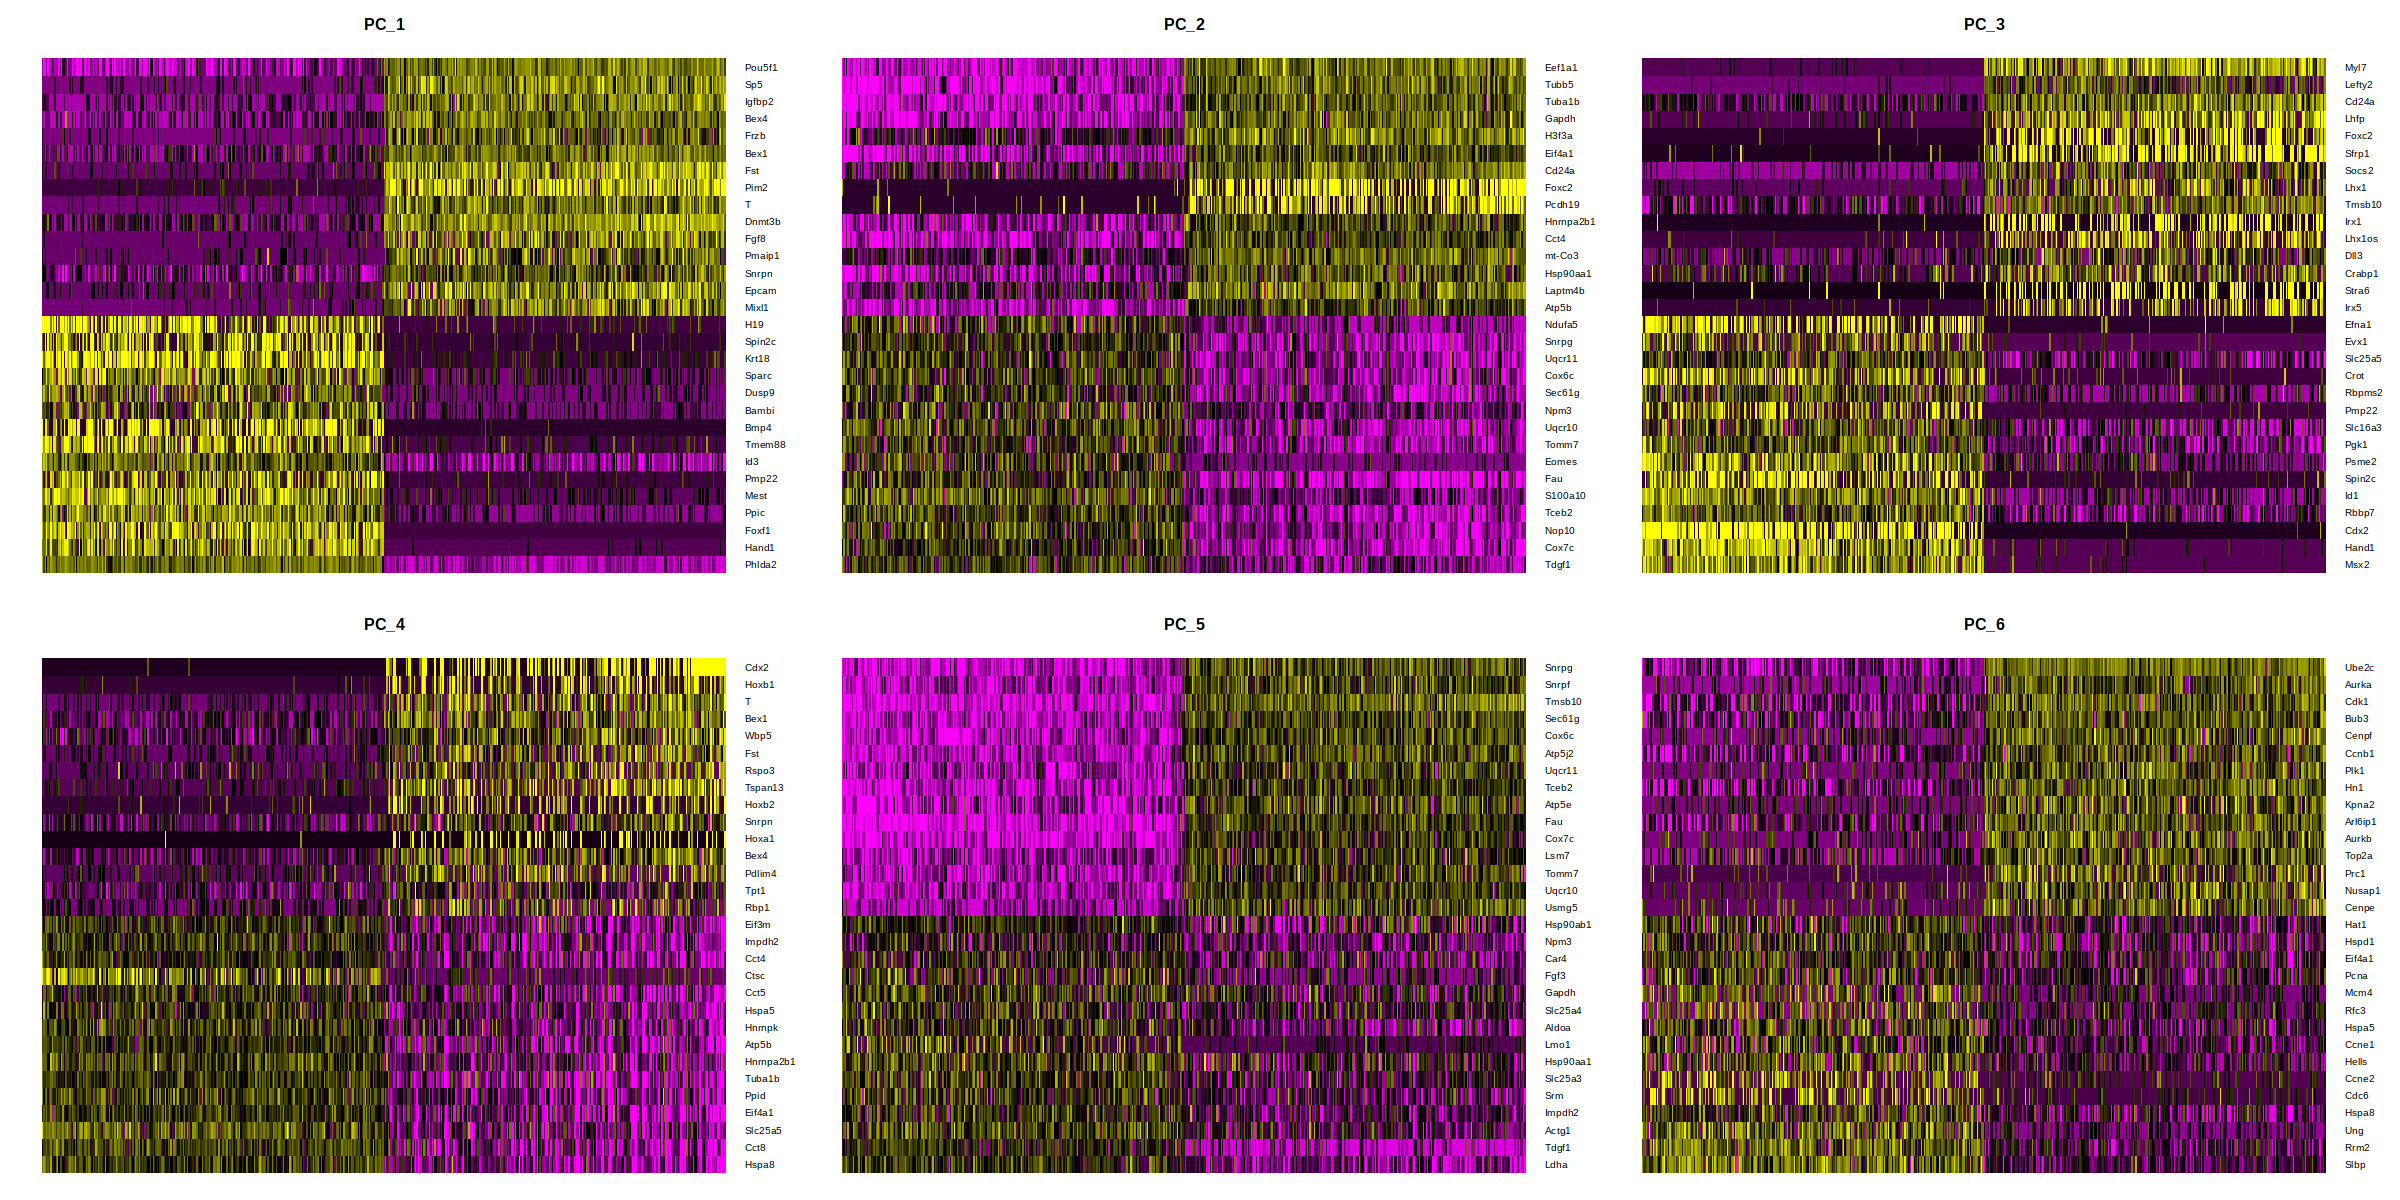

In [114]:
options(repr.plot.width = 20, repr.plot.height = 10)
DimHeatmap(seurat, dims = 1:6, cells = 500, balanced = TRUE)

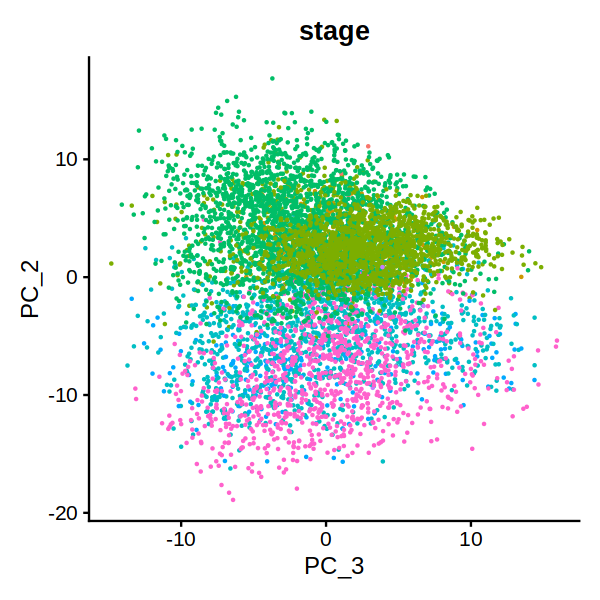

In [118]:
options(repr.plot.width = 5, repr.plot.height = 5)
DimPlot(seurat, reduction = "pca", group.by = 'stage', dims = c(3,2)) + NoLegend()


# FastMNN batch correction

In [261]:
test = fastMNN(rna.sce, 
               batch = rna.sce$stage)

Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”


In [262]:
library(destiny)
DiffusionMap <- DiffusionMap(reducedDim(test,"corrected"))

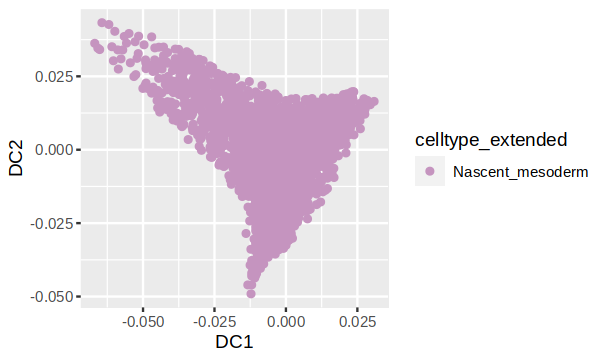

In [263]:
# Fetch UMAP coordinates
to.plot <- DiffusionMap@eigenvectors %>% as.data.table(., keep.rownames = T) %>% setnames('rn', 'cell') %>% 
    .[,cell:=colnames(test)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(DC1, DC2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

In [264]:
patternGenes = fread(file.path(args$outdir, 'patternGenes_v2.txt.gz'))
endGenes = fread(file.path(args$outdir, 'endGenes_v2.txt.gz'))

In [265]:
genes_keep = unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene)

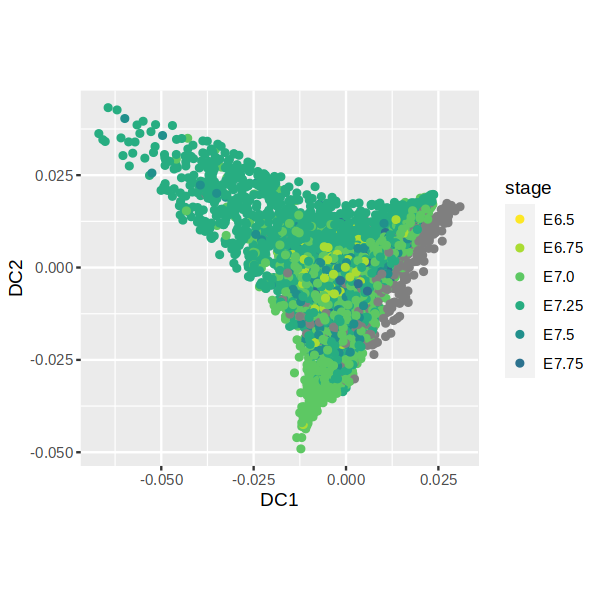

In [296]:
ggplot(to.plot[order(gene)], aes(DC1, DC2, color = stage)) + 
    geom_point() +  
    scale_color_manual(values = opts$stage.colors) + 
    coord_fixed()

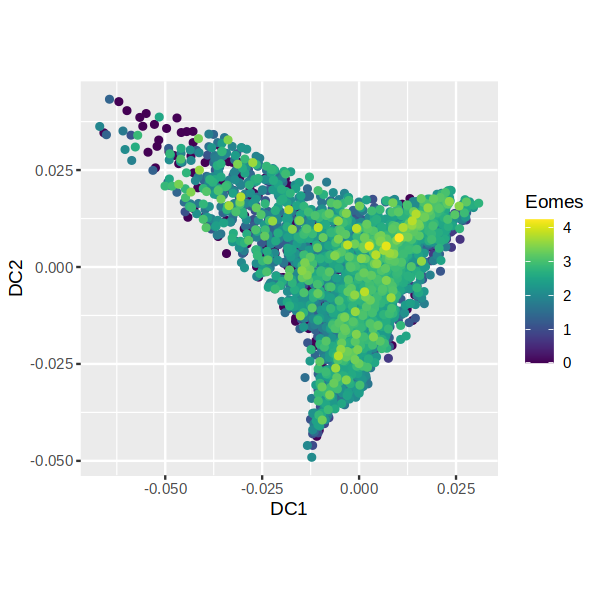

In [297]:
gene = 'Eomes'
options(repr.plot.height=5, repr.plot.width=5)
to.plot$gene = as.numeric(logcounts(rna.sce[gene,to.plot$cell]))

ggplot(to.plot[order(gene)], aes(DC1, DC2, color = gene)) + 
    geom_point() + 
    viridis::scale_color_viridis(name = gene) + 
    coord_fixed()

In [337]:
library(destiny)
genes = head(genes_keep, 100)
genes = c(
    'Vegfc', 'Kdr','Notch1', 'Ptch2', 'Fzd7',  'Frzb', 
    'Igf2', 'Igf2r', 'Notch3', 'Dlk1', 'Wnt5a','Lgr4',
    'Bmp2','Tdgf1', 'Tgfbr3','Lefty2','Fgf10','Pdgfrb',
    'Bmp7', 'Bambi', 'Tgfb2', 'Smad9', 'Fgf15', 'Fgf18',
        'Eomes', 'Lhx1', 'Nfatc1', 'Etv2', 'Sox7', 'Tal1',
          'Snai2', 'Hand1', 'Hoxa10',  'Smad3','Sox6', 'Tbx4')
DiffusionMap <- DiffusionMap(rna.sce[genes,])

Warning message in (function (data, k, ..., query = NULL, distance = c("euclidean", :
“find_knn does not yet support sparse matrices, converting data to a dense matrix.”


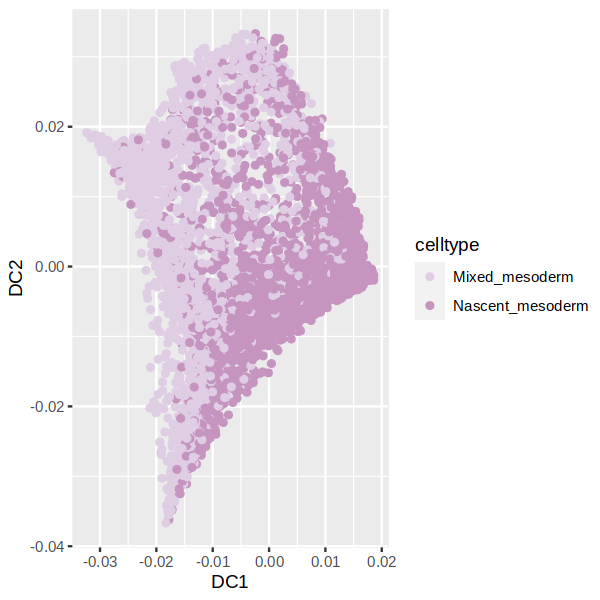

In [340]:
# Fetch UMAP coordinates
to.plot <- DiffusionMap@eigenvectors %>% as.data.table(., keep.rownames = T) %>% setnames('rn', 'cell') %>% 
    .[,cell:=colnames(rna.sce)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(DC1, DC2, color = celltype)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype.colors)

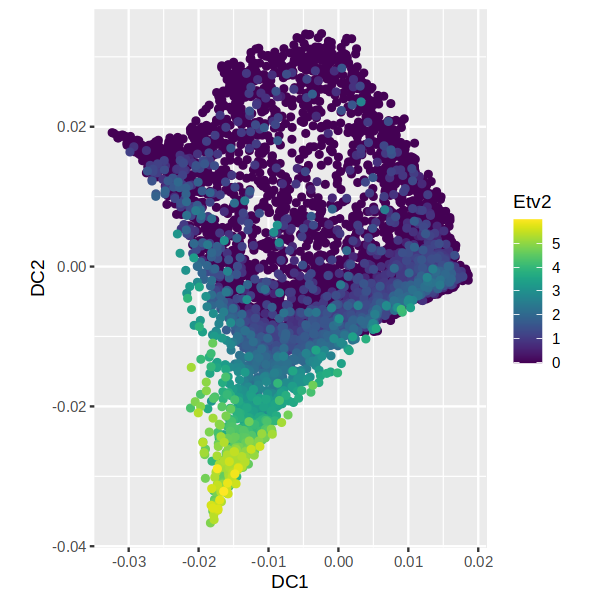

In [341]:
gene = 'Etv2'
options(repr.plot.height=5, repr.plot.width=5)
to.plot$gene = as.numeric(logcounts(rna.sce[gene,to.plot$cell]))

ggplot(to.plot[order(gene)], aes(DC1, DC2, color = gene)) + 
    geom_point() + 
    viridis::scale_color_viridis(name = gene) + 
    coord_fixed()

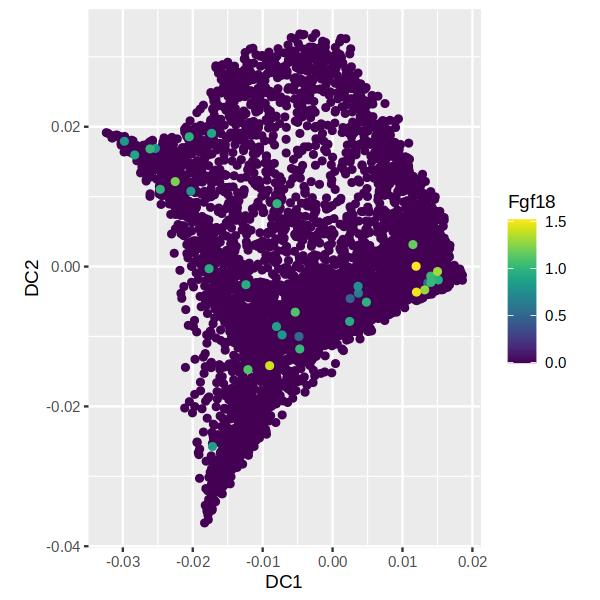

In [342]:
gene = 'Fgf18'
options(repr.plot.height=5, repr.plot.width=5)
to.plot$gene = as.numeric(logcounts(rna.sce[gene,to.plot$cell]))

ggplot(to.plot[order(gene)], aes(DC1, DC2, color = gene)) + 
    geom_point() + 
    viridis::scale_color_viridis(name = gene) + 
    coord_fixed()

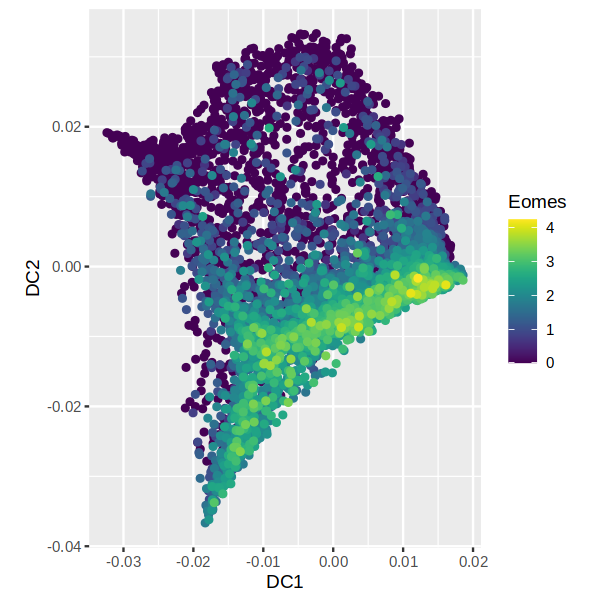

In [343]:
gene = 'Eomes'
options(repr.plot.height=5, repr.plot.width=5)
to.plot$gene = as.numeric(logcounts(rna.sce[gene,to.plot$cell]))

ggplot(to.plot[order(gene)], aes(DC1, DC2, color = gene)) + 
    geom_point() + 
    viridis::scale_color_viridis(name = gene) + 
    coord_fixed()

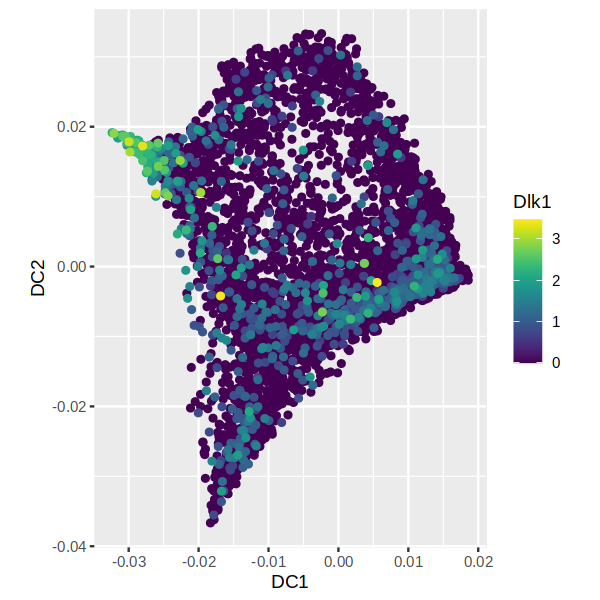

In [344]:
gene = 'Dlk1'
options(repr.plot.height=5, repr.plot.width=5)
to.plot$gene = as.numeric(logcounts(rna.sce[gene,to.plot$cell]))

ggplot(to.plot[order(gene)], aes(DC1, DC2, color = gene)) + 
    geom_point() + 
    viridis::scale_color_viridis(name = gene) + 
    coord_fixed()

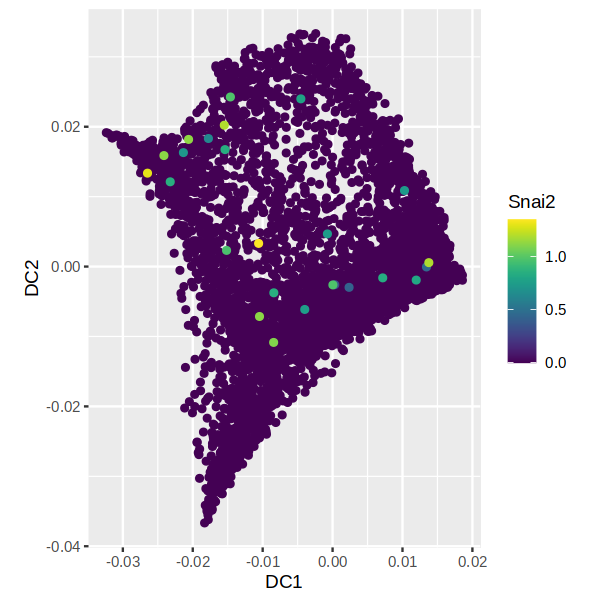

In [351]:
gene = 'Snai2'
options(repr.plot.height=5, repr.plot.width=5)
to.plot$gene = as.numeric(logcounts(rna.sce[gene,to.plot$cell]))

ggplot(to.plot[order(gene)], aes(DC1, DC2, color = gene)) + 
    geom_point() + 
    viridis::scale_color_viridis(name = gene) + 
    coord_fixed()

In [381]:
unique(fread(args$metadata)$celltype)

[1] "Epiblast"                       "Primitive_Streak"              
 [3] "ExE_ectoderm"                   "Visceral_endoderm"             
 [5] "ExE_endoderm"                   "Nascent_mesoderm"              
 [7] "Rostral_neurectoderm"           "Blood_progenitors_2"           
 [9] "Mixed_mesoderm"                 "ExE_mesoderm"                  
[11] "Intermediate_mesoderm"          "Pharyngeal_mesoderm"           
[13] "Caudal_epiblast"                "PGC"                           
[15] "Mesenchyme"                     "Haematoendothelial_progenitors"
[17] "Blood_progenitors_1"            "Surface_ectoderm"              
[19] "Gut"                            "Paraxial_mesoderm"             
[21] "Caudal_neurectoderm"            "Notochord"                     
[23] "Somitic_mesoderm"               "Caudal_Mesoderm"               
[25] "Erythroid1"                     "Def._endoderm"                 
[27] "Parietal_endoderm"              "Allantois"                     
[29] "Anterior_Primitive_Streak"      "Endothelium"                   
[31] "Forebrain_Midbrain_Hindbrain"   "Spinal_cord"                   
[33] "Cardiomyocytes"                 "Erythroid2"                    
[35] "NMP"                            "Erythroid3"                    
[37] "Neural_crest"

In [406]:
# load meta
meta = fread(args$metadata)

celltypes = c(
              'Nascent_mesoderm',
              'Mixed_mesoderm',
              'Intermediate_mesoderm',
              'Mesenchyme', 'Allantois', 'Haematoendothelial_progenitors'
)

meta = meta[celltype %in% celltypes]

In [407]:
# load sce
rna.sce <- rna.sce_full[,meta$cell]
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [408]:
source(here::here('rna/mapping/run/mnn/mapping_functions.R'))
library(batchelor)

# FastMNN batch correction

In [409]:
genes_keep = head(unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene), 500)

In [410]:
test = fastMNN(rna.sce[genes_keep,], 
               batch = rna.sce$stage)

Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”


In [411]:
library(destiny)
DiffusionMap <- DiffusionMap(reducedDim(test,"corrected"))

In [412]:
test <- runUMAP(test, dimred="corrected", n_neighbors = 35, min_dist = 0.15)

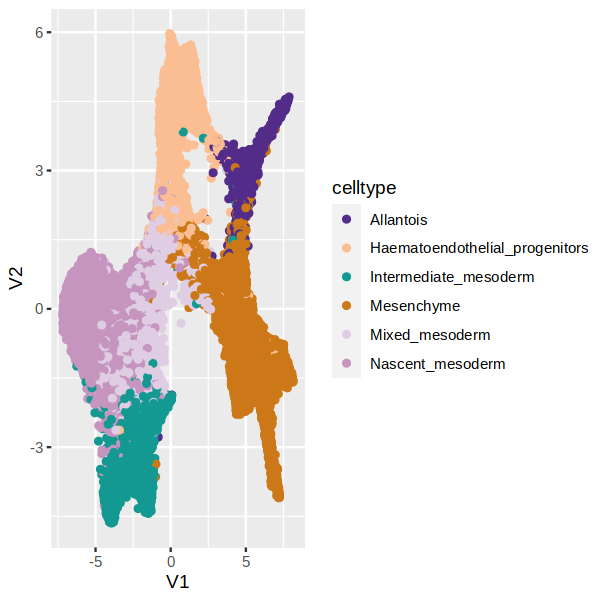

In [413]:
# Fetch UMAP coordinates
to.plot <- reducedDim(test,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(test)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(V1, V2, color = celltype)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype.colors)

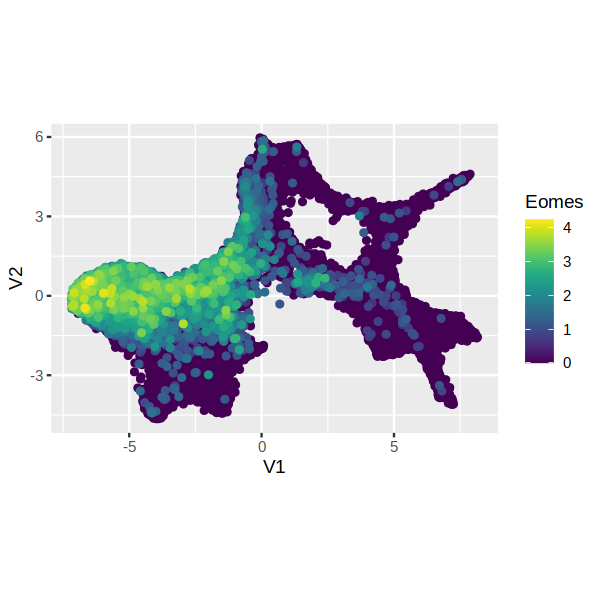

In [414]:
gene = 'Eomes'
options(repr.plot.height=5, repr.plot.width=5)
to.plot$gene = as.numeric(logcounts(rna.sce[gene,to.plot$cell]))

ggplot(to.plot[order(gene)], aes(V1, V2, color = gene)) + 
    geom_point() + 
    viridis::scale_color_viridis(name = gene) + 
    coord_fixed()

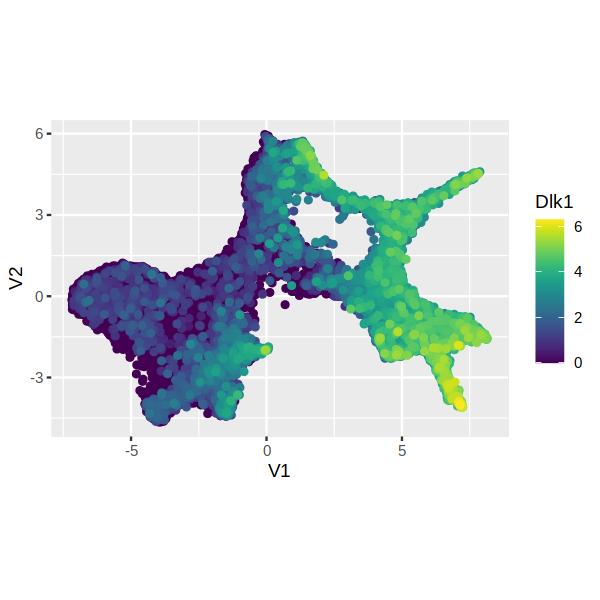

In [415]:
gene = 'Dlk1'
options(repr.plot.height=5, repr.plot.width=5)
to.plot$gene = as.numeric(logcounts(rna.sce[gene,to.plot$cell]))

ggplot(to.plot[order(gene)], aes(V1, V2, color = gene)) + 
    geom_point() + 
    viridis::scale_color_viridis(name = gene) + 
    coord_fixed()

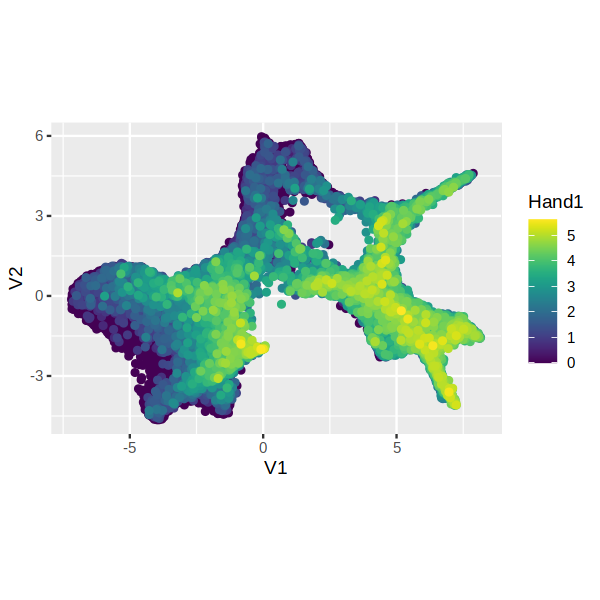

In [416]:
gene = 'Hand1'
options(repr.plot.height=5, repr.plot.width=5)
to.plot$gene = as.numeric(logcounts(rna.sce[gene,to.plot$cell]))

ggplot(to.plot[order(gene)], aes(V1, V2, color = gene)) + 
    geom_point() + 
    viridis::scale_color_viridis(name = gene) + 
    coord_fixed()

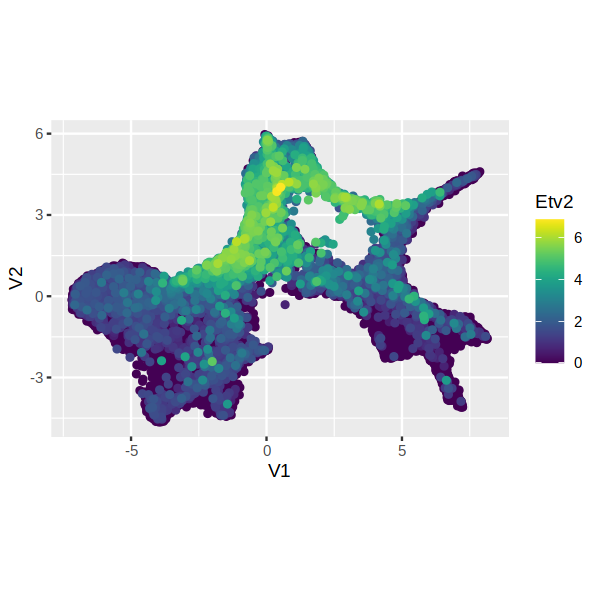

In [417]:
gene = 'Etv2'
options(repr.plot.height=5, repr.plot.width=5)
to.plot$gene = as.numeric(logcounts(rna.sce[gene,to.plot$cell]))

ggplot(to.plot[order(gene)], aes(V1, V2, color = gene)) + 
    geom_point() + 
    viridis::scale_color_viridis(name = gene) + 
    coord_fixed()

In [119]:
# load meta
meta = fread(args$metadata)

celltypes = c(
              'Primitive_Streak',
              'Nascent_mesoderm',
              'Mixed_mesoderm',
              'Lateral_plate_mesoderm',
              'Allantois',
              'Haematoendothelial_progenitors', 
              'Blood_progenitors'
)

meta = meta[celltype_extended %in% celltypes]

In [120]:
# load sce
rna.sce <- rna.sce_full[,meta$cell]
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [121]:
source(here::here('rna/mapping/run/mnn/mapping_functions.R'))
library(batchelor)

# FastMNN batch correction

In [122]:
seurat = as.Seurat(rna.sce)

In [123]:
all_genes = rownames(seurat)
non_informative = all_genes[grep("*Rik|^Gm|^Rps|^Rpl|^Olfr", all_genes)] # Mt genes kept for this analysis
seurat = seurat[!rownames(seurat) %in% non_informative,]

In [124]:
seurat <- FindVariableFeatures(seurat, selection.method = "vst", nfeatures = 2000)


In [125]:
test = fastMNN(rna.sce[VariableFeatures(object = seurat),], 
               batch = rna.sce$stage)

In [126]:
library(destiny)
DiffusionMap <- DiffusionMap(reducedDim(test,"corrected"))


Attaching package: ‘destiny’


The following object is masked from ‘package:SummarizedExperiment’:

    distance


The following object is masked from ‘package:GenomicRanges’:

    distance


The following object is masked from ‘package:IRanges’:

    distance


Warning message:
“as(<dsCMatrix>, "dsTMatrix") is deprecated since Matrix 1.5-0; do as(., "TsparseMatrix") instead”


In [127]:
test_bu = test

In [128]:
test <- runUMAP(test, dimred="corrected", n_neighbors = 35, min_dist = 0.15)

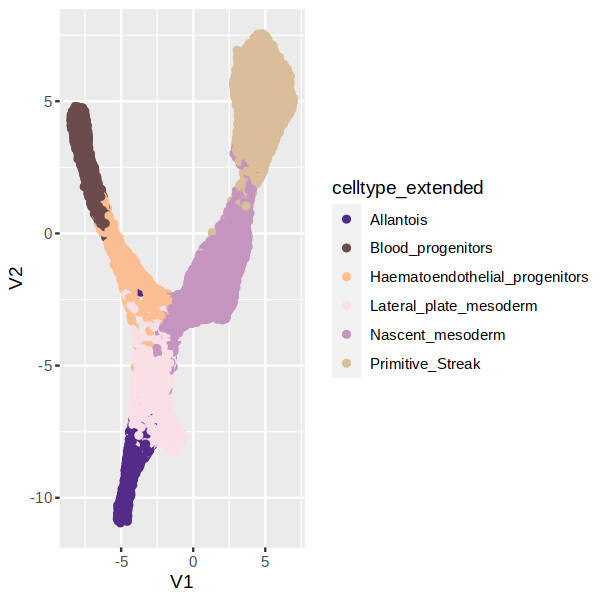

In [129]:
# Fetch UMAP coordinates
to.plot <- reducedDim(test,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(test)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(V1, V2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)

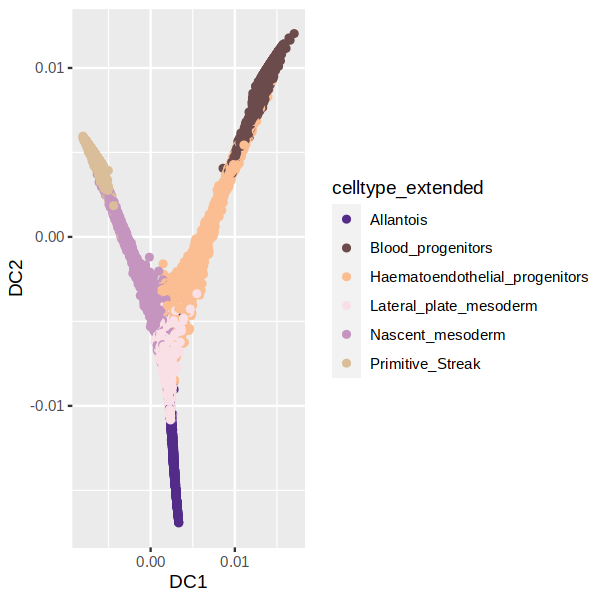

In [130]:
# Fetch UMAP coordinates
to.plot <- DiffusionMap@eigenvectors %>% as.data.table(., keep.rownames = T) %>% setnames('rn', 'cell') %>% 
    .[,cell:=colnames(test)] %>%
    merge(meta, by="cell")

ggplot(to.plot, aes(DC1, DC2, color = celltype_extended)) + 
    geom_point() + 
    scale_color_manual(values = opts$celltype_extended.colors)